# Reproducing Andersen+26 Figures

Here we provide code for reproducing Figures 3-16 in Andersen+26 (if you want the `pptx` files used to create Figure 1 + 2, contact the corresponding author, Bridget C. Andersen). 

If you wish to run through this notebook, you will need to download the digest for each simulation (see Table 11 in Andersen+26 and Step 5 in `Simulate_Run_PATH.ipynb`) at this Google Drive link: [link](https://drive.google.com/drive/folders/1Rv6koYfKJ7yQ5xYV666gIaMQ2wX0A6Tg?usp=drive_link). The files are descriptively named: 

`digest_<loc>_<intrinsic_offset_distribution>_<offset_prior>_<magnitude_prior>_<unseen_prior>_<catalog>.parquet`

For example, `digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet` is a simulation with the "CK" localization (see the top of Figure 6 of Andersen+26), an exponential intrinsic offset distribution, an exponential PATH offset prior, an inverse magnitude prior, a unseen prior of $P(U) = 0.15$, run with the `DECALs` catalog (the first entry in Table 11).

For the estimation of $P(U)$ (Figure 7), you will also need to download both of the pre-queried PATH catalogs at this Google Drive link: [link](https://drive.google.com/drive/folders/1PKqh8tnDLbtqIuGeoPFEEh60ovs8Zjw8?usp=drive_link)
- `Pan-STARRS`: download `catalog_dudxmmlss_hecate_Pan-STARRS.parquet`
- `DECaLs`: download `catalog_dudxmmlss_hecate_DECaL.parquet`

See Section 3.3 of Andersen+24 and Step 4 of `Simulate_Run_PATH.ipynb` for a description of these catalogs. Fair warning: these files are very large, 900 MB and 6.1 GB for `Pan-STARRS` and `DECaLs`, respectively. 


Download each of these files and save them in the directory defined by the `FRB_APATH` environmental variable.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)
import matplotlib

import os
import pandas as pd
import numpy as np
from importlib.resources import files
from pathlib import Path
import random
import scipy

In [9]:
from frb.dm import prob_dmz
import scipy.stats as stats
from scipy.interpolate import CloughTocher2DInterpolator
from astropy.cosmology.realizations import Planck18 as cosmo
from astropy import units as u
from astropath.simulations import load_galaxy_catalog
from astropath.simulations import utils as sim_utils

In [3]:
# Set the directory where simulation data and catalogs are downloaded
os.environ['FRB_APATH'] = '/Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/'

## Figure 3

In [4]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize.parquet')
df = pd.read_parquet(fn)

In [5]:
# Load DMs from CHIME/FRB Catalog 1 with S/N > 12
fn = files('astropath.data') / 'frb_surveys' / 'chimefrbcat1.csv'
df_dr1 = pd.read_csv(fn)
chime_dms_eg = np.nanmean([df_dr1['dm_exc_ne2001'].values,df_dr1['dm_exc_ymw16'].values], axis=0)
chime_snrs = df_dr1['bonsai_snr']
threshold = 12.
chime_observed_dms_eg = chime_dms_eg[chime_snrs > threshold]
print(f"Observed CHIME/FRB DMs: N={len(chime_observed_dms_eg)}, median={np.median(chime_observed_dms_eg):.0f}" + r"$\rm pc cm^{-3}$")

Observed CHIME/FRB DMs: N=402, median=411$\rm pc cm^{-3}$


In [6]:
# Calculate KDE of Catalog 1 DMs
DMex = df['dmex_host'].values
kernel = stats.gaussian_kde(DMex)
dms = np.linspace(0., 3000, 500)
DMex_kde = kernel(dms)

# Grab simulated redshifts
zs = df['z_host'].values

In [7]:
# Load the survey-specific P(z,DM) grid
# First load grid to get z and DM arrays (they're the same for all)
grid_data = prob_dmz.grab_repo_grid('CHIME_pzdm.npz')
z = grid_data['z']
DM_EG = grid_data['DM']
grid = grid_data['pzdm']
pzDM = grid.flatten()

DM, Z = np.meshgrid(DM_EG, z)  # 2D grid for interpolation
interp = CloughTocher2DInterpolator(list(zip(Z.ravel(), DM.ravel())), grid.ravel(), fill_value=np.nan)
# Make new regular grid of z, dm coordinates
z_new_list = np.linspace(0, 2.5, 500)
dm_new_list = np.linspace(0, 4000, 500)
z_new, dm_new = np.meshgrid(z_new_list, dm_new_list)
Pz_dm_interp = interp(z_new, dm_new)
Pz_dm_interp[Pz_dm_interp < 0.] = 0.

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz


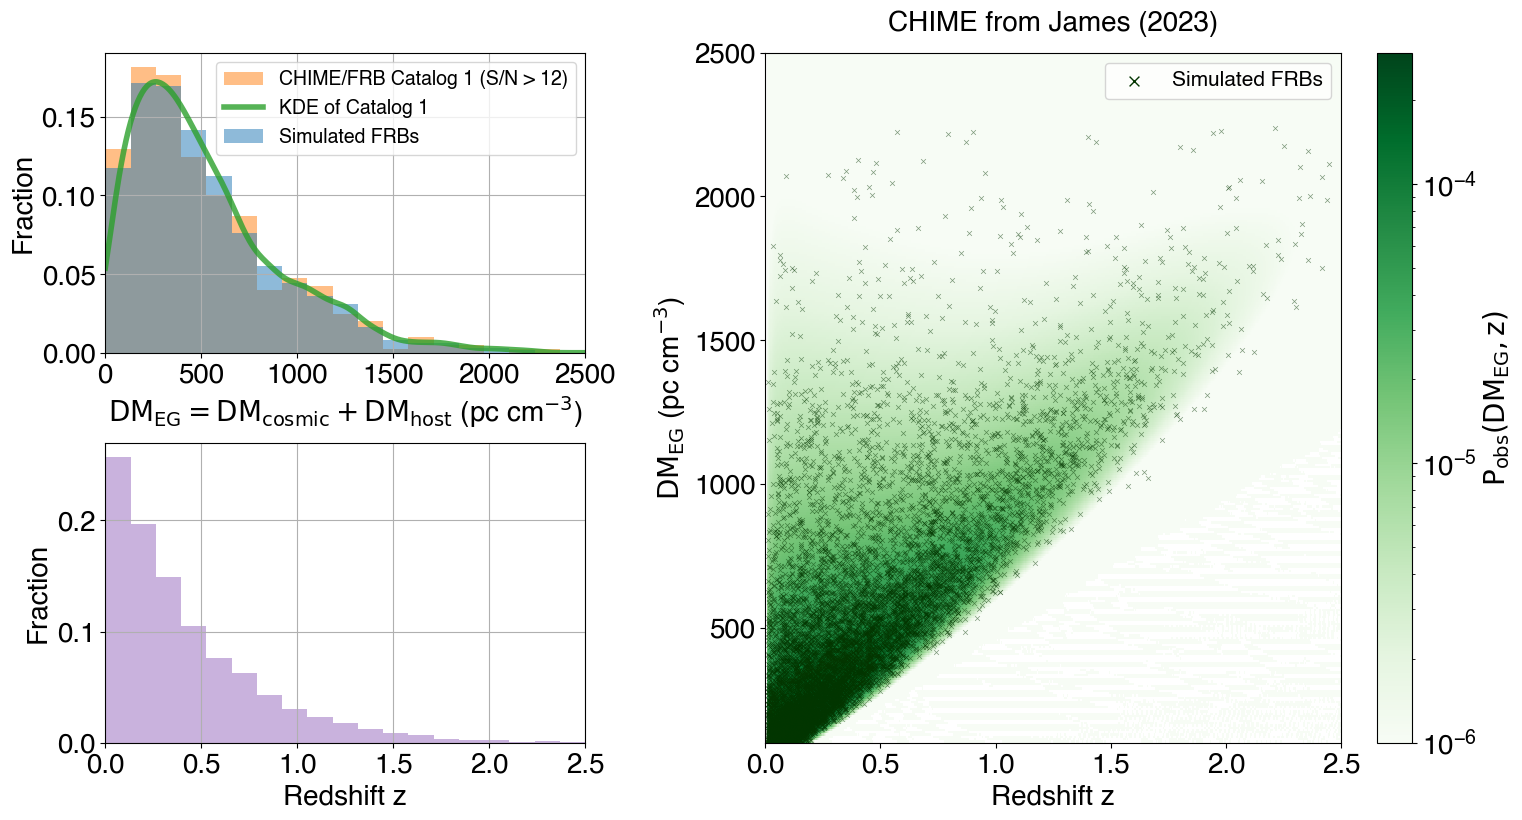

In [21]:
fig = plt.figure(figsize=(12, 6))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
height = 1/2.
sep_h = 0.15
width = 0.4
sep_w = 0.15
ax_z = (0., 0., width, height)
ax_dmeg = (0., (height+sep_h), width, height)
ax_pzdm = (width+sep_w, 0., 0.6, height*2+sep_h)

ax = plt.axes(ax_pzdm)
my_cmap = matplotlib.colormaps['Greens'] # copy the default cmap, cubehelix
# my_cmap.set_bad((0,0,0))
pc = ax.pcolormesh(
    z_new, dm_new, Pz_dm_interp, cmap=my_cmap, 
    norm=matplotlib.colors.LogNorm(vmin=1e-6), # vmin=1e-6, vmax=2e-4
    rasterized=True,
)
plt.colorbar(pc, label=r'$\rm P_{obs}(DM_{EG},z)$')
# plt.scatter(z_samp, DM_EG_samp, color='xkcd:lightish blue', alpha=.5, s=12, linewidth=0.5, edgecolor='xkcd:dark blue', rasterized=True)
plt.scatter(zs, DMex, marker='x', color='xkcd:dark green', alpha=.5, s=12, linewidth=0.5, rasterized=True, label='Simulated FRBs')
plt.xlim([0, 2.5])
plt.ylim([100, 2500])
plt.xlabel('Redshift z')
plt.ylabel(r'$\rm DM_{EG}$ (pc cm$^{-3}$)')#' = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.title(r'CHIME from James (2023)', fontsize=20, y=1.02) #  $\rm P_{obs}(z|DM_{EG})$
leg = plt.legend(fontsize=15)
for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_sizes([50])
    lh.set_linewidth([1])
    
ax = plt.axes(ax_dmeg)
bins = np.linspace(0,2500,20)
density = False
weights = np.ones_like(chime_observed_dms_eg) / float(len(chime_observed_dms_eg))
counts, bin_edges, _ = plt.hist(chime_observed_dms_eg, bins=bins, color=cycle[1], weights=weights, density=density, alpha=0.5, label='CHIME/FRB Catalog 1 (S/N > 12)')
bin_width = np.diff(bin_edges)[0]  # array of bin widths
N = len(DMex)
norm = N * bin_width  # one per bin
plt.plot(dms, DMex_kde * norm / float(len(DMex)), color=cycle[2], alpha=0.8, lw=4, label='KDE of Catalog 1')#  / np.nanmax(DMex_kde)*np.nanmax(hist[0])
weights = np.ones_like(DMex) / float(len(DMex))
hist = plt.hist(DMex, bins=bins, color=cycle[0], weights=weights, density=density, alpha=0.5, label='Simulated FRBs')
plt.xlim([0,2500])
plt.ylabel('Fraction')
plt.grid(zorder=1)
plt.legend(fontsize=14)
# _ = plt.yticks(np.arange(0, 1000+1, 500))
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')

ax = plt.axes(ax_z)
bins = np.linspace(0,2.5,20)
weights = np.ones_like(zs) / float(len(zs))
hist = plt.hist(zs, bins=bins, weights=weights, density=density, color=cycle[4], alpha=0.5)
plt.ylabel('Fraction')
plt.xlim([0,2.5])
plt.grid(zorder=1)
plt.xlabel(r'Redshift z')

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'frb_props_redo_norm.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 4

In [22]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
df = pd.read_parquet(fn)

In [23]:
# Load in the combined host catalog
combined_catalog_fn = os.path.join(os.getenv('FRB_APATH'), 'combined_HSC_PS1_HECATE_galaxies.parquet')
combined_catalog = pd.read_parquet(combined_catalog_fn)

In [24]:
# Get absolute magnitudes of 46 known FRB hosts
fn = files('astropath.data') / 'frb_surveys' / 'Lz_host_data.csv' # From Alexa Gordon, complete up to Shannon+24
df_known = pd.read_csv(fn)
# Scale mrs with z's to find distribution of Mrs
mrs = np.array(df_known['r-band'])
zs_mrs = np.array(df_known['redshift'])
# Get luminosity distance
ds = cosmo.luminosity_distance(zs_mrs).to(u.parsec).value
# Calculate absolute magnitudes
Mrs = mrs - 5. * np.log10(ds) + 5

# Calculate KDE of absolute magnitudes
kernel = stats.gaussian_kde(Mrs)
mags = np.linspace(-25., -15., 500)
Mr_kde = kernel(mags)

# Get simulated absolute magnitudes
Mrs_sim = df['frb_Mr']

# Get simulated apparent magnitudes
host_m_r = df['frb_mr']

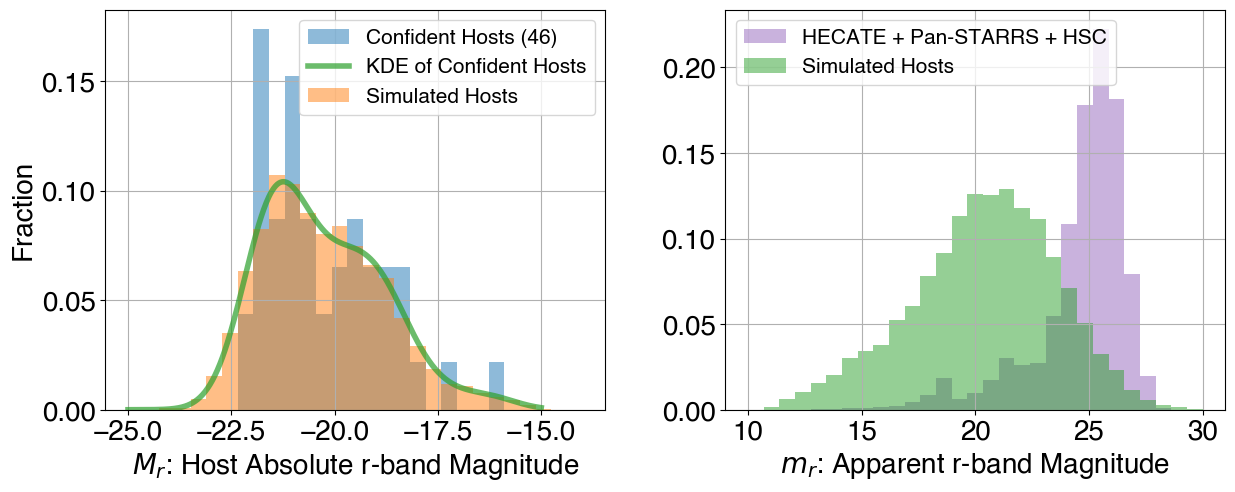

In [29]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.5
sep_w = 0.12
Mr_ax = (0., 0., width, 1.)
mr_ax = (width+sep_w, 0., width, 1.)

fig = plt.figure(figsize=(10,4))

ax = plt.axes(Mr_ax)
bins = np.linspace(-25, -14, 30)
weights = np.ones_like(Mrs) / float(len(Mrs))
counts, bin_edges, _ = plt.hist(Mrs, bins=bins, color=cycle[0], lw=4, alpha=0.5, weights=weights, density=False, label=f"Confident Hosts ({len(Mrs)})")
bin_width = np.diff(bin_edges)[0]  # array of bin widths
N = len(Mrs)
norm = N * bin_width  # one per bin
plt.plot(mags, Mr_kde * norm / float(len(Mrs)), color=cycle[2], lw=4, label='KDE of Confident Hosts', alpha=0.7)
weights = np.ones_like(Mrs_sim) / float(len(Mrs_sim))
hist = plt.hist(Mrs_sim, bins=bins, color=cycle[1], weights=weights, density=False, alpha=0.5, label='Simulated Hosts')
plt.xlabel('$M_r$: Host Absolute r-band Magnitude')
plt.ylabel('Fraction')
plt.legend(fontsize=15)
plt.grid(zorder=1)

ax = plt.axes(mr_ax)
bins = np.linspace(10, 30, 30)
inds = np.random.randint(low=0, high=len(combined_catalog), size=500000)
weights = np.ones_like(combined_catalog.iloc[inds]['mag']) / float(len(combined_catalog.iloc[inds]['mag']))
hist, bins, _ = plt.hist(combined_catalog.iloc[inds]['mag'], bins=bins, color=cycle[4], lw=4, alpha=0.5, density=False, weights=weights, label=f"HECATE + Pan-STARRS + HSC")
weights = np.ones_like(host_m_r) / float(len(host_m_r))
hist, bins, _ = plt.hist(host_m_r, bins=bins, color=cycle[2], lw=4, alpha=0.5, density=True, weights=weights, label=f"Simulated Hosts")
plt.grid(zorder=1)
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.legend(fontsize=15, loc='upper left')

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'Mr_distribution_redo_norm.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 5

In [26]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
df = pd.read_parquet(fn)

In [27]:
# Load in the combined host catalog
combined_catalog_fn = os.path.join(os.getenv('FRB_APATH'), 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet')
combined_catalog = pd.read_parquet(combined_catalog_fn)

In [28]:
# Load in the pre-queried galaxy catalog
fn = 'catalog_dudxmmlss_hecate_DECaL.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_DECaL.parquet


In [31]:
# Vectorized catalog identification (works for astropy Table or pandas DataFrame)
conditions = [
    ~np.isnan(combined_catalog['DECaL_ID'].astype(float)),
    ~np.isnan(combined_catalog['HSC_ID'].astype(float)),
    combined_catalog['SDSS_PHOTID'] != None,
]
choices = ['DECaL', 'HSC', 'HECATE']

orig_catalog = np.select(conditions, choices, default='')
orig_ras = np.array(combined_catalog['ra'])
orig_decs  = np.array(combined_catalog['dec'])

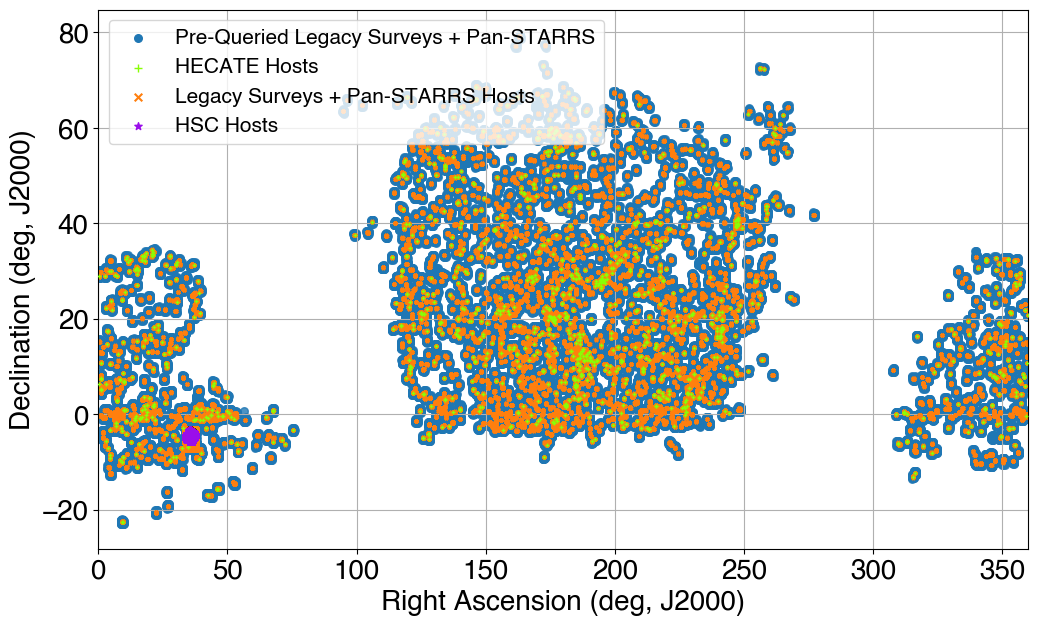

In [32]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig = plt.figure(figsize=(12,7))

plot_cat = path_catalog[::1000]
plt.scatter(plot_cat['ra'], plot_cat['dec'], color=cycle[0], s=30, alpha=0.8, label='Pre-Queried Legacy Surveys + Pan-STARRS', rasterized=True, zorder=1)
plt.scatter(orig_ras[orig_catalog == 'HECATE'], orig_decs[orig_catalog == 'HECATE'], color='xkcd:lime green', s=10, linewidths=1, alpha=1, marker='+', label='HECATE Hosts', rasterized=True, zorder=3)
plt.scatter(orig_ras[orig_catalog == 'DECaL'], orig_decs[orig_catalog == 'DECaL'], color=cycle[1], s=5, alpha=1, marker='x', label='Legacy Surveys + Pan-STARRS Hosts', rasterized=True, zorder=2)
plt.scatter(orig_ras[orig_catalog == 'HSC'], orig_decs[orig_catalog == 'HSC'], color='xkcd:violet', s=10, alpha=1, linewidths=1, marker='*', label='HSC Hosts', rasterized=True, zorder=4)
plt.xlabel('Right Ascension (deg, J2000)') # amethyst
plt.ylabel('Declination (deg, J2000)')
lgnd = plt.legend(loc='upper left', fontsize=15)
plt.xlim([0,360])
plt.grid()
# Set a visible legend marker
for l in lgnd.legend_handles:
    l._sizes = [30]
    l._alpha = [1.]

plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'selected_hosts_by_catalog_recolor.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 6

In [5]:
# Create localization PDFs
def gauss(x, A, x0, sigma):
    return A*np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

def rot(theta):
    theta = np.deg2rad(theta)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])

# Set coordinate axes
xlim = 60.
ylim = 60.
n = 3000
xs = np.linspace(-xlim, xlim, n)
ys = np.linspace(-ylim, ylim, n)
xv, yv = np.meshgrid(xs, ys)

# Find the Dec of a source at the middle of the CHIME beam
CHIMELATITUDE = 49.3207092194
ra = 0.
dec = CHIMELATITUDE

# Calculate example baseline geometry
baseline_chime_kko = (0.8648973412830646, -0.09890619626160913) # delta RA, delta DEC
delta_ra = baseline_chime_kko[0] * np.cos(np.deg2rad(dec))
delta_dec = baseline_chime_kko[1]
theta_chime_kko = np.arctan(delta_dec / delta_ra)*180./np.pi

baseline_chime_gbo = (-0.8423109600080678, 0.051083016134590764)
delta_ra = baseline_chime_gbo[0] * np.cos(np.deg2rad(dec))
delta_dec = baseline_chime_gbo[1]
theta_chime_gbo = np.arctan(delta_dec / delta_ra)*180./np.pi

baseline_chime_hco = (0.14097467392243537, 0.5636802823022435)
delta_ra = baseline_chime_hco[0] * np.cos(np.deg2rad(dec))
delta_dec = baseline_chime_hco[1]
theta_chime_hco = np.arctan(delta_dec / delta_ra)*180./np.pi

# CHIME baseband
mu_x = 0.
mu_y = 0.
sig_x = 25.
sig_xy = 0.
sig_y = 25.
angle = 0.
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_baseband = rv.pdf(np.dstack((xv, yv)))

# CHIME KKO
mu_x = 0.
mu_y = 0.
sig_x = 2.
sig_xy = 0.
sig_y = 10000.
angle = theta_chime_kko
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_kko = rv.pdf(np.dstack((xv, yv)))

# CHIME GBO
mu_x = 0.
mu_y = 0.
sig_x = 50. / 1000.
sig_xy = 0.
sig_y = 1000.
angle = theta_chime_gbo
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_gbo = rv.pdf(np.dstack((xv, yv)))

# CHIME HCO
mu_x = 0.
mu_y = 0.
sig_x = 100. / 1000.
sig_xy = 0.
sig_y = 1000.
angle = theta_chime_hco
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_hco = rv.pdf(np.dstack((xv, yv)))

# DSA
mu_x = 0.
mu_y = 0.
sig_x = 1.
sig_xy = 0.
sig_y = 1.
angle = 0.
cov_mat = np.array([[sig_x**2, sig_xy], [sig_xy, sig_y**2]])
cov_mat_rot = rot(angle) @ cov_mat @ rot(angle).T # np.matmul(cov_mat, rot(angle))
rv = scipy.stats.multivariate_normal([mu_x, mu_y], cov_mat_rot)
z_dsa = rv.pdf(np.dstack((xv, yv)))

# Pre-calculate pdfs
pdf_baseband = z_baseband
pdf_kko = z_baseband*z_kko
pdf_gbo = z_baseband*z_kko*z_gbo
pdf_hco = z_baseband*z_kko*z_gbo*z_hco
pdf_dsa = z_dsa

In [6]:
# Load in simulations digest for each localization region
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b25pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
df_baseband = pd.read_parquet(fn)

fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
df_kko = pd.read_parquet(fn)

fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a15b0pa5_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
df_gbo = pd.read_parquet(fn)

fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a0b0pa10_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
df_hco = pd.read_parquet(fn)

fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a1b1pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
df_dsa = pd.read_parquet(fn)

Plotting Localization PDFs
CHIME-Only
CHIME-KKO
CHIME-KKO-GBO
CHIME-KKO-GBO-HCRO
1"
Plotting P(O|x) vs magnitude for correct associations
CHIME-Only
CHIME-KKO
CHIME-KKO-GBO
1"
CHIME-KKO-GBO-HCRO
Plotting P(O|x) vs magnitude for incorrect associations
CHIME-Only
CHIME-KKO
CHIME-KKO-GBO
1"
CHIME-KKO-GBO-HCRO
Plotting galactocentric offset distributions
CHIME-Only
CHIME-KKO
CHIME-KKO-GBO
1"
CHIME-KKO-GBO-HCRO


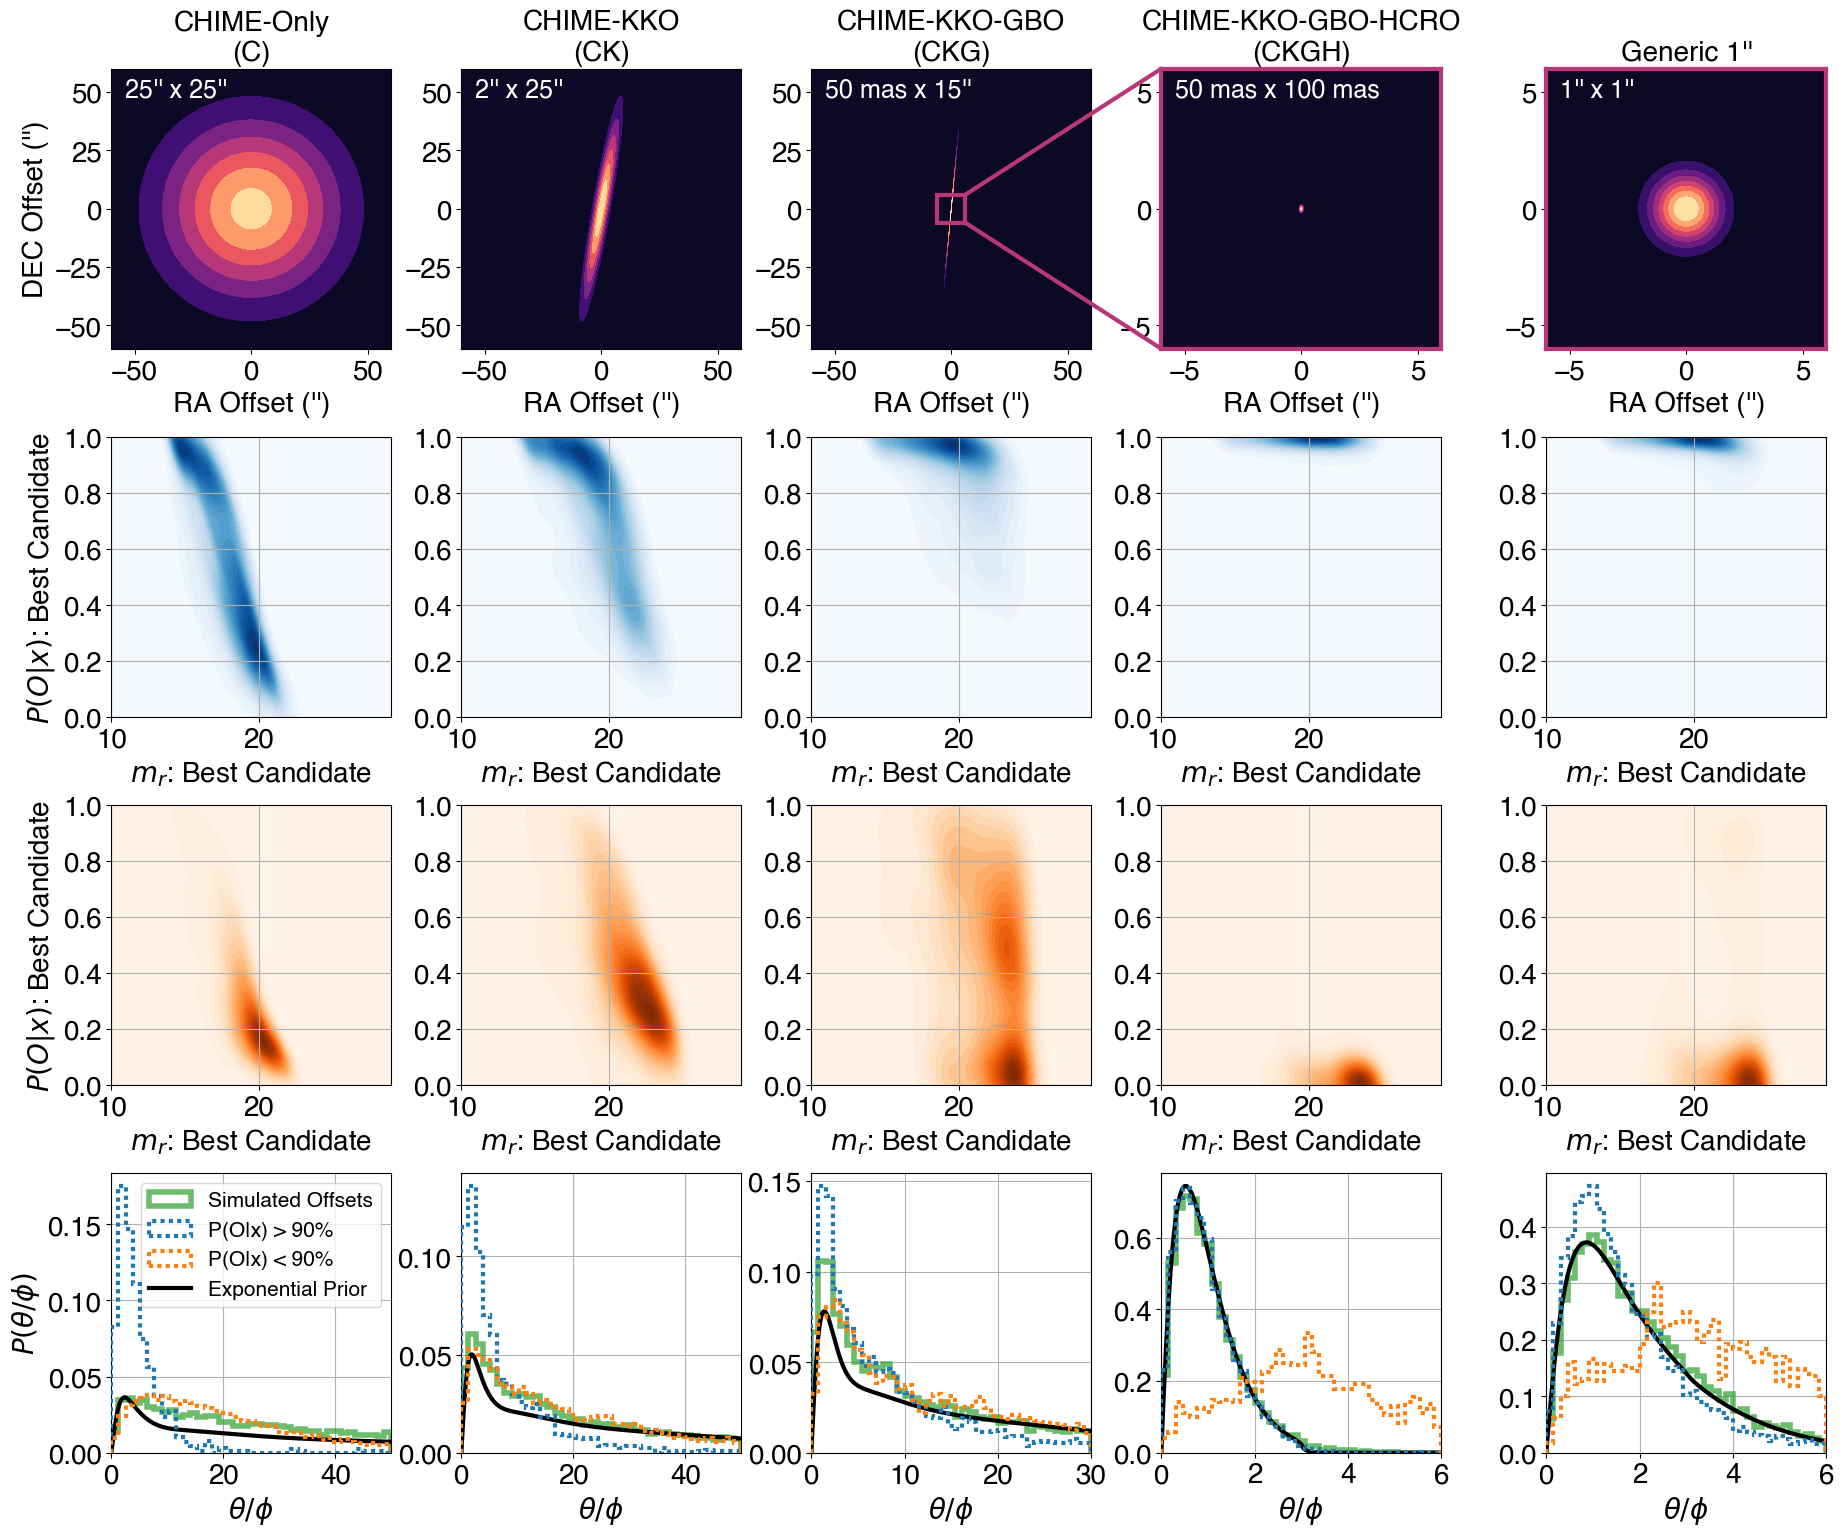

In [7]:
width_tot = 7*2
height_tot = 11*2
fig = plt.figure(figsize=(width_tot,height_tot))

###########################################################################################
################################## Plot Localizations #####################################
###########################################################################################
print('Plotting Localization PDFs')

# (left, bottom, width, height)
width = 1/5.
sep_w = 0.05
height_loc = width * width_tot/height_tot
baseband_loc = (0., 0.8, width, height_loc)
kko_loc = ((width + sep_w), 0.8, width, height_loc)
gbo_loc = ((width + sep_w)*2, 0.8, width, height_loc)
hco_loc = ((width + sep_w)*3, 0.8, width, height_loc)
dsa_loc = ((width + sep_w)*4.1, 0.8, width, height_loc)

print('CHIME-Only')
ax_baseband = plt.axes(baseband_loc)
plt.contourf(xv, yv, pdf_baseband, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
plt.ylabel("DEC Offset ('')")
plt.title('CHIME-Only\n(C)')
plt.text(0.05, 0.9, "25'' x 25''", color='white', fontsize=18, transform=ax_baseband.transAxes)

print('CHIME-KKO')
ax_kko = plt.axes(kko_loc)
plt.contourf(xv, yv, pdf_kko, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
plt.title('CHIME-KKO\n(CK)')
plt.text(0.05, 0.9, "2'' x 25''", color='white', fontsize=18, transform=ax_kko.transAxes)

print('CHIME-KKO-GBO')
ax_gbo = plt.axes(gbo_loc)
plt.contourf(xv, yv, pdf_gbo, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
plt.title('CHIME-KKO-GBO\n(CKG)')
plt.text(0.05, 0.9, "50 mas x 15''", color='white', fontsize=18, transform=ax_gbo.transAxes)

print('CHIME-KKO-GBO-HCRO')
ax_hco = plt.axes(hco_loc)
plt.contourf(xv, yv, pdf_hco, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
# ax.set_yticklabels([])
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.title('CHIME-KKO-GBO-HCRO\n(CKGH)')
plt.text(0.05, 0.9, "50 mas x 100 mas", color='white', fontsize=18, transform=ax_hco.transAxes)

print('1"')
ax_dsa = plt.axes(dsa_loc)
plt.contourf(xv, yv, pdf_dsa, levels=7, cmap='magma')
plt.xlabel("RA Offset ('')")
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.title("Generic 1''")
plt.text(0.05, 0.9, "1'' x 1''", color='white', fontsize=18, transform=ax_dsa.transAxes)

# --- Zoom box ---
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch

# The zoom region on GBO corresponds to the HCO axis limits
zoom_x1, zoom_x2 = -6, 6   # match ax_hco xlim
zoom_y1, zoom_y2 = -6, 6   # match ax_hco ylim

# Draw rectangle on GBO panel
rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=3, edgecolor='#b73779', facecolor='none', linestyle='-'
)
ax_gbo.add_patch(rect)

# Connect top-right corner of rectangle to top-left corner of HCO axes
# Corners: pick two that make visual sense given the panels are side by side
# Here we connect the right-side corners of the zoom box to the left-side of HCO
for gbo_corner, hco_corner in [
    ((zoom_x2, zoom_y2), (0, 1)),   # top-right GBO -> top-left HCO (axes coords)
    ((zoom_x2, zoom_y1), (0, 0)),   # bottom-right GBO -> bottom-left HCO
]:
    con = ConnectionPatch(
        xyA=gbo_corner, coordsA=ax_gbo.transData,
        xyB=hco_corner, coordsB=ax_hco.transAxes,
        color='#b73779', linewidth=3, linestyle='-'
    ) # #eb5760 or #b73779
    plt.gcf().add_artist(con)
    
for ax in [ax_hco, ax_dsa]:
    for spine in ax.spines.values():
        spine.set_edgecolor('#b73779')
        spine.set_linewidth(3)
    ax.set_yticks([-5, 0, 5])

###########################################################################################
################################ Plot Correct Magnitudes ##################################
###########################################################################################

print("Plotting P(O|x) vs magnitude for correct associations")

# (left, bottom, width, height)
width = 1/5.
sep_w = 0.05
height_loc = width * width_tot/height_tot
sep_h = 0.04
baseband_tmag = (0., 0.8-(height_loc+sep_h), width, height_loc)
kko_tmag = ((width + sep_w), 0.8-(height_loc+sep_h), width, height_loc)
gbo_tmag = ((width + sep_w)*2, 0.8-(height_loc+sep_h), width, height_loc)
hco_tmag = ((width + sep_w)*3, 0.8-(height_loc+sep_h), width, height_loc)
dsa_tmag = ((width + sep_w)*4.1, 0.8-(height_loc+sep_h), width, height_loc)

print('CHIME-Only')
ax = plt.axes(baseband_tmag)
digest = df_baseband
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.ylabel(r'$P(O|x)$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO')
ax = plt.axes(kko_tmag)
digest = df_kko
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO-GBO')
ax = plt.axes(gbo_tmag)
digest = df_gbo
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('1"')
ax = plt.axes(dsa_tmag)
digest = df_dsa
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO-GBO-HCRO')
ax = plt.axes(hco_tmag)
digest = df_hco
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = correct_associations['mag_cand']
y = correct_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Blues', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

###########################################################################################
################################# Plot False Magnitudes ####################################
###########################################################################################

print("Plotting P(O|x) vs magnitude for incorrect associations")

# (left, bottom, width, height)
width = 1/5.
sep_w = 0.05
height_loc = width * width_tot/height_tot
sep_h = 0.04
baseband_fmag = (0., 0.8-(height_loc+sep_h)*2, width, height_loc)
kko_fmag = ((width + sep_w), 0.8-(height_loc+sep_h)*2, width, height_loc)
gbo_fmag = ((width + sep_w)*2, 0.8-(height_loc+sep_h)*2, width, height_loc)
hco_fmag = ((width + sep_w)*3, 0.8-(height_loc+sep_h)*2, width, height_loc)
dsa_fmag = ((width + sep_w)*4.1, 0.8-(height_loc+sep_h)*2, width, height_loc)

print('CHIME-Only')
ax = plt.axes(baseband_fmag)
digest = df_baseband
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.ylabel(r'$P(O|x)$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO')
ax = plt.axes(kko_fmag)
digest = df_kko
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO-GBO')
ax = plt.axes(gbo_fmag)
digest = df_gbo
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('1"')
ax = plt.axes(dsa_fmag)
digest = df_dsa
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

print('CHIME-KKO-GBO-HCRO')
ax = plt.axes(hco_fmag)
digest = df_hco
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]
# Number of contour levels
n_levels = 30
x = incorrect_associations['mag_cand']
y = incorrect_associations['P_Ox']
xmin, xmax = 10, 29
ymin, ymax = 0, 1
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
cfset = plt.contourf(xx, yy, f, cmap='Oranges', levels=n_levels, extent=[xmin, xmax, ymin, ymax])
plt.xlabel(r'$m_r$: Best Candidate')
plt.grid(zorder=20)

# ###########################################################################################
# ##################################### Plot Offsets ########################################
# ###########################################################################################

print('Plotting galactocentric offset distributions')

# (left, bottom, width, height)
width = 1/5.
sep_w = 0.05
height_loc = width * width_tot/height_tot
sep_h = 0.04
baseband_toff = (0., 0.8-(height_loc+sep_h)*3, width, height_loc)
kko_toff = ((width + sep_w), 0.8-(height_loc+sep_h)*3, width, height_loc)
gbo_toff = ((width + sep_w)*2, 0.8-(height_loc+sep_h)*3, width, height_loc)
hco_toff = ((width + sep_w)*3, 0.8-(height_loc+sep_h)*3, width, height_loc)
dsa_toff = ((width + sep_w)*4.1, 0.8-(height_loc+sep_h)*3, width, height_loc)

lw=4
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
bins = np.linspace(0, 10, 25)
density = True

print('CHIME-Only')
ax = plt.axes(baseband_toff)
digest = df_baseband
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.ylabel(r'$P(\theta/\phi)$')
plt.legend(fontsize=15)
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('CHIME-KKO')
ax = plt.axes(kko_toff)
digest = df_kko
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('CHIME-KKO-GBO')
ax = plt.axes(gbo_toff)
digest = df_gbo
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('1"')
ax = plt.axes(dsa_toff)
digest = df_dsa
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('CHIME-KKO-GBO-HCRO')
ax = plt.axes(hco_toff)
digest = df_hco
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

print('Saving plot')
plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'sim_pdf_mags_redo_draft2_nolabels.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [49]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


def azimuthal_integrated_prior(u, theta_prior):
    """
    1D radial PDF p(u) where u = theta/phi (unchanged from original).
    """
    u = np.asarray(u, dtype=float)
    p = np.zeros_like(u)

    if theta_prior['PDF'] == 'exp':
        s     = theta_prior.get('scale', 1.0)
        max_v = theta_prior['max']
        max_u = max_v * s
        ok    = u <= max_u
        norm  = s**2 * (1 - (1 + max_v) * np.exp(-max_v))
        p[ok] = u[ok] * np.exp(-u[ok] / s) / norm

    elif theta_prior['PDF'] == 'uniform':
        max_u = theta_prior['max']
        ok    = u <= max_u
        p[ok] = 2 * u[ok] / max_u**2

    elif theta_prior['PDF'] == 'core':
        max_u = theta_prior['max']
        ok    = u <= max_u
        norm  = max_u - np.log(1 + max_u)
        p[ok] = u[ok] / (u[ok] + 1) / norm

    return p


def _sample_prior(u, p_prior, n, rng):
    """
    Draw n samples from the 1D radial prior p(u) via inverse-CDF.
    Works for any prior shape (exp, uniform, core, ...).
    """
    du  = u[1] - u[0]
    cdf = np.cumsum(p_prior) * du
    cdf /= cdf[-1]                             # guard against float rounding
    return np.interp(rng.uniform(0., 1., n), cdf, u)


def convolve_prior_with_loc(u, p_prior, a_over_phi, b_over_phi,
                             u_obs=None, n_mc=200_000, rng=None):
    """
    Convolve the 1D radial prior with an elliptical Gaussian localisation
    kernel via Monte Carlo sampling.

    WHY MC IS NECESSARY FOR ELONGATED BEAMS
    ----------------------------------------
    For a circular Gaussian (a = b = σ), azimuthal averaging of the 2D
    convolution gives the Rice formula:

        K_rice(r | r') = (r/σ²) exp(-(r²+r'²)/2σ²) I₀(rr'/σ²)

    For an ELLIPTICAL Gaussian the exact azimuthally-averaged kernel in
    Fourier space is:

        Ḡ_ell(k) = exp(-k²(a²+b²)/4) · I₀(k²(a²−b²)/4)

    The Rice approximation simply drops the I₀ factor.  For CHIME-KKO
    (a=25'', b=2'') at k=0.1 phi⁻¹: I₀ ≈ 75×.  No choice of σ_eff can
    compensate for this — the kernel has the wrong *shape*, not just the
    wrong width.  MC replicates exactly what the simulation does and is
    therefore correct for any beam aspect ratio.

    Parameters
    ----------
    u : np.ndarray          Uniformly spaced prior grid (theta/phi)
    p_prior : np.ndarray    Prior values on u
    a_over_phi : float      Major-axis 1-sigma in units of phi
    b_over_phi : float      Minor-axis 1-sigma in units of phi
    u_obs : np.ndarray      Output grid; auto-sized if None
    n_mc : int              Number of MC draws (larger = smoother curve)
    rng : np.random.Generator

    Returns
    -------
    u_obs : np.ndarray
    p_obs : np.ndarray  (normalised)
    """
    if rng is None:
        rng = np.random.default_rng(42)

    du = u[1] - u[0]

    # --- sample true 2D positions from the prior ---
    u_true = _sample_prior(u, p_prior, n_mc, rng)
    az     = rng.uniform(0., 2. * np.pi, n_mc)
    x_true = u_true * np.cos(az)
    y_true = u_true * np.sin(az)

    # --- add independent elliptical Gaussian noise ---
    # PA doesn't affect the azimuthally-averaged radial distribution,
    # so we can always align the axes with x/y.
    eps_x = rng.normal(0., a_over_phi, n_mc)
    eps_y = rng.normal(0., b_over_phi, n_mc)
    u_obs_samp = np.sqrt((x_true + eps_x) ** 2 + (y_true + eps_y) ** 2)

    # --- output grid ---
    if u_obs is None:
        sig_max   = max(a_over_phi, b_over_phi)
        u_obs_max = max(2. * u[-1], u[-1] + 5. * sig_max)
        u_obs     = np.arange(0., u_obs_max + du, du)

    # --- histogram → normalised density ---
    bins   = np.concatenate([u_obs, [u_obs[-1] + du]])
    p_obs, _ = np.histogram(u_obs_samp, bins=bins, density=True)
    p_obs  = np.maximum(p_obs, 0.)
    norm   = np.sum(p_obs) * du
    if norm > 0:
        p_obs /= norm

    return u_obs, p_obs


def stack_convolved_prior(u, theta_prior, frb_df, phi_col='ang_size_host',
                          n_mc=500_000, seed=42, smooth_sigma=1.0):
    """
    Average the MC-convolved prior over a population of FRBs, each with
    its own localisation ellipse and host half-light radius.

    The true FRB positions are pre-sampled ONCE from the prior and reused
    for every FRB (common-random-numbers trick), which reduces MC variance
    across the stack without introducing bias.

    Parameters
    ----------
    u : np.ndarray
    theta_prior : dict
    frb_df : pd.DataFrame
        Must have columns 'a', 'b' (1-sigma semi-axes, arcsec) and phi_col.
    phi_col : str
    n_mc : int
        MC draws per FRB.  500 k gives <0.5 % noise per bin after stacking.
    seed : int
    smooth_sigma : float
        Width (in bins) of a final Gaussian smoothing pass to remove
        histogram noise.  Set to 0 to skip.  Default 1 bin ≈ du phi units.

    Returns
    -------
    u_obs : np.ndarray   common output grid
    p_stacked : np.ndarray   mean convolved prior, normalised to 1
    """
    rng    = np.random.default_rng(seed)
    du     = u[1] - u[0]
    p_prior = azimuthal_integrated_prior(u, theta_prior)

    # --- pre-sample true 2D positions (shared across all FRBs) ---
    u_true = _sample_prior(u, p_prior, n_mc, rng)
    az     = rng.uniform(0., 2. * np.pi, n_mc)
    x_true = u_true * np.cos(az)
    y_true = u_true * np.sin(az)

    # --- common output grid (covers the worst-localised FRB in the sample) ---
    a_arr   = frb_df['a'].values
    b_arr   = frb_df['b'].values
    phi_arr = frb_df[phi_col].values
    sig_max_all = (np.maximum(a_arr, b_arr) / phi_arr).max()

    u_obs_max = max(2. * u[-1], u[-1] + 5. * sig_max_all)
    u_obs     = np.arange(0., u_obs_max + du, du)
    bins      = np.concatenate([u_obs, [u_obs[-1] + du]])

    stacked = np.zeros(len(u_obs))

    for _, frb in frb_df.iterrows():
        a_phi = frb.a   / frb[phi_col]   # major-axis sigma in phi units
        b_phi = frb.b   / frb[phi_col]   # minor-axis sigma in phi units

        # independent noise per FRB; true positions reused from above
        eps_x = rng.normal(0., a_phi, n_mc)
        eps_y = rng.normal(0., b_phi, n_mc)
        u_obs_i = np.sqrt((x_true + eps_x) ** 2 + (y_true + eps_y) ** 2)

        hist, _ = np.histogram(u_obs_i, bins=bins, density=True)
        stacked += hist

    stacked /= len(frb_df)

    # light smoothing to remove histogram granularity
    if smooth_sigma > 0:
        stacked = gaussian_filter1d(stacked, sigma=smooth_sigma)

    norm = np.sum(stacked) * du
    if norm > 0:
        stacked /= norm

    return u_obs, stacked

CHIME-KKO


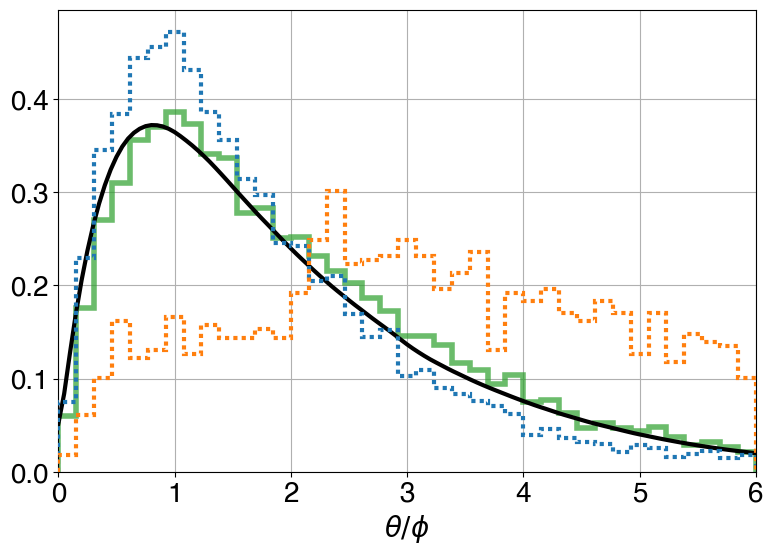

In [53]:
fig = plt.figure(figsize=(9,6))

print('CHIME-KKO')
ax = plt.axes()
digest = df_dsa
# Calculate PATH prior convolved with localization
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')
# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True
# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')
# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 
# Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',
# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')
plt.xlabel(r'$\theta/\phi$')
plt.xlim([0,theta_max])
plt.grid(zorder=20)

## Figure 7

In [133]:
# First, load in the pre-queried DECaL galaxy catalog
fn = 'catalog_dudxmmlss_hecate_DECaL.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_DECaL.parquet


In [134]:
# Load in simulations digest for each localization region
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet')
digest = pd.read_parquet(fn)
digest_filt = sim_utils.calculate_unseen(digest, path_catalog, thresh_cross_match=2.)

Starting cross-matching (will take a minute)...
Cross-matching finished. Time elapsed: 0.303 minutes


In [143]:
# Calculate the fraction unseen in each magnitude bin
mag_bin_edges = np.arange(10.5, 28., 1.)
mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.

# Jackknife to get errors
N = 500
unseen_jn_data_decals = []
for kk in range(N):
    # Remove 1/5 of points
    inds = random.sample(range(len(digest_filt)), int(len(digest_filt)/5))
    digest_jn = digest_filt.iloc[inds]
    
    unseen_fraction = []
    for ii in range(len(mag_bin_edges)-1):
        mag_start_bin = mag_bin_edges[ii]
        mag_end_bin = mag_bin_edges[ii+1]
        in_bin = (digest_jn['mag_host'] >= mag_start_bin) & (digest_jn['mag_host'] <= mag_end_bin)
        digest_in_bin = digest_jn[in_bin]
        digest_unseen = digest_in_bin[digest_in_bin['unseen']]
        if len(digest_in_bin) == 0:
            unseen_frac = np.nan
        elif mag_start_bin < 14.5:
            unseen_frac = 0.
        else:
            unseen_frac = len(digest_unseen) / len(digest_in_bin)
        unseen_fraction.append(unseen_frac)
    mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.
    unseen_jn_data_decals.append(unseen_fraction)

In [144]:
# Now, do the same for the pre-queried Pan-STARRS galaxy catalog
fn = 'catalog_dudxmmlss_hecate_Pan-STARRS.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_Pan-STARRS.parquet


In [145]:
# Load in simulations digest for each localization region
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet')
digest = pd.read_parquet(fn)
digest_filt = sim_utils.calculate_unseen(digest, path_catalog, thresh_cross_match=2.)

Starting cross-matching (will take a minute)...
Cross-matching finished. Time elapsed: 0.284 minutes


In [146]:
# Calculate the fraction unseen in each magnitude bin
mag_bin_edges = np.arange(10.5, 28., 1.)
mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.

# Jackknife to get errors
N = 500
unseen_jn_data_ps1 = []
for kk in range(N):
    # Remove 1/5 of points
    inds = random.sample(range(len(digest_filt)), int(len(digest_filt)/5))
    digest_jn = digest_filt.iloc[inds]
    
    unseen_fraction = []
    for ii in range(len(mag_bin_edges)-1):
        mag_start_bin = mag_bin_edges[ii]
        mag_end_bin = mag_bin_edges[ii+1]
        in_bin = (digest_jn['mag_host'] >= mag_start_bin) & (digest_jn['mag_host'] <= mag_end_bin)
        digest_in_bin = digest_jn[in_bin]
        digest_unseen = digest_in_bin[digest_in_bin['unseen']]
        if len(digest_in_bin) == 0:
            unseen_frac = np.nan
        elif mag_start_bin < 14.5:
            unseen_frac = 0.
        else:
            unseen_frac = len(digest_unseen) / len(digest_in_bin)
        unseen_fraction.append(unseen_frac)
    mag_bin_centers = (mag_bin_edges[:-1] + mag_bin_edges[1:]) / 2.
    unseen_jn_data_ps1.append(unseen_fraction)

In [148]:
# Load in generated FRBs for each of the relevant telescopes
generated_frbs_fn = os.path.join(os.getenv('FRB_APATH'), 'generated_frbs_chime.parquet')
frbs_chime = pd.read_parquet(generated_frbs_fn)

generated_frbs_fn = os.path.join(os.getenv('FRB_APATH'), 'generated_frbs_dsa.parquet')
frbs_dsa = pd.read_parquet(generated_frbs_fn)

generated_frbs_fn = os.path.join(os.getenv('FRB_APATH'), 'generated_frbs_craftics.parquet')
frbs_askap = pd.read_parquet(generated_frbs_fn)

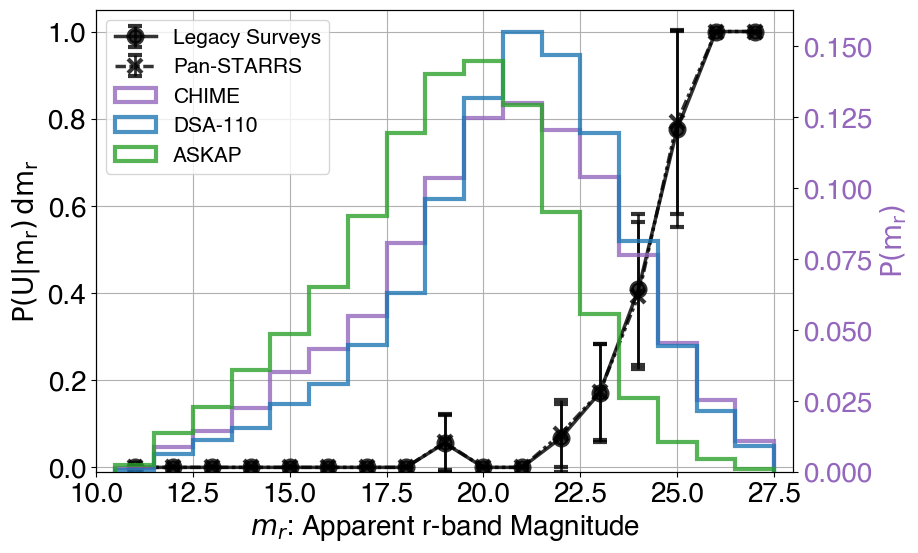

In [149]:
# Now plot!
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], cycle[4], 'black']
markers = ['x', '+', 'd', '*', 'o']
marker_sizes = [100, 150, 80, 100, 80]
linestyles = ['-', '--', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (1, 1))]

fig = plt.figure(figsize=(9,6))

# Plot P(U) dm_r
ax1 = plt.gca()
plt.errorbar(
    mag_bin_centers, np.nanmean(unseen_jn_data_decals, axis=0) / np.nanmax(np.nanmean(unseen_jn_data_decals, axis=0)), yerr=np.nanstd(unseen_jn_data_decals, axis=0), 
    capsize=5, elinewidth=2, lw=2.5, markersize=marker_sizes[0]/10, mew=3, color='black', 
    marker='o', alpha=0.8, label='Legacy Surveys',
) 
plt.errorbar(
    mag_bin_centers, np.nanmean(unseen_jn_data_ps1, axis=0) / np.nanmax(np.nanmean(unseen_jn_data_ps1, axis=0)), yerr=np.nanstd(unseen_jn_data_ps1, axis=0), 
    capsize=5, elinewidth=2, lw=2.5, markersize=marker_sizes[0]/10, mew=3, color='black', 
    marker='x', alpha=0.8, label='Pan-STARRS', linestyle=linestyles[-2],
) 
plt.ylabel(r'$\rm P(U|m_r)\,dm_r$')
plt.xlim([10,28])
plt.ylim([-0.01,1.05])
plt.grid(zorder=20)
plt.xlabel('$m_r$: Apparent r-band Magnitude')
lines, labels = ax1.get_legend_handles_labels()

# Plot the CHIME magnitude distribution
ax2 = ax1.twinx()
bins = np.arange(10.5, 28., 1.)
density = True
Ns_chime, bins, _ = plt.hist(
    frbs_chime['m_r'], bins=bins, density=density, 
    histtype='step', lw=3,
    color=colors[-2], alpha=0.8, label='CHIME',
)
Ns_dsa, bins, _ = plt.hist(
    frbs_dsa['m_r'], bins=bins, density=density, 
    histtype='step', lw=3,
    color=colors[0], alpha=0.8, label='DSA-110',
)
Ns_askap, bins, _ = plt.hist(
    frbs_askap['m_r'], bins=bins, density=density, 
    histtype='step', lw=3,
    color=colors[2], alpha=0.8, label='ASKAP', 
)
ax2.tick_params(axis='y', labelcolor=colors[-2])
ax2.set_ylabel(r'$\rm P(m_r)$', color=colors[-2])

lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, fontsize=15, loc='upper left')

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'plots', 'paper_plot_data', 'PU_decals_ps1.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [156]:
# Calculate P(U) for CHIME and DECaL
PU_dmrs = np.nanmean(unseen_jn_data_decals, axis=0)
PU = np.nansum(Ns_chime * PU_dmrs) / np.nansum(Ns_chime)
print(f"CHIME + DECaL P(U): {PU:.2f}")

CHIME + DECaL P(U): 0.13


In [157]:
# Calculate P(U) for CHIME and Pan-STARRS
PU_dmrs = np.nanmean(unseen_jn_data_ps1, axis=0)
PU = np.nansum(Ns_chime * PU_dmrs) / np.nansum(Ns_chime)
print(f"CHIME + Pan-STARRS P(U): {PU:.2f}")

CHIME + DECaL P(U): 0.14


## Figure 8

In [9]:
survey_str = 'DECaL'
P_Ox_thresh = 0.9
P_Us = np.linspace(0., 1., 11)

fp_rates_all = {}
tp_rates_all = {}
for loc in ['a25b2pa12', 'a25b2pa12', 'a25b2pa12', 'a25b2pa12', 'a25b2pa12']: # 'a25b25pa0', 'a25b2pa12', 'GBO', 'DSA110', 'HCO'
    fp_rates = []
    tp_rates = []
    print(loc)
    for P_U in P_Us:
        fn = os.path.join(os.getenv('FRB_APATH'), f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet')
        digest = pd.read_parquet(fn)
        
        match_criteria_TP = (digest['correct_association']) & (digest['P_Ox'] > P_Ox_thresh)
        match_criteria_FN = (digest['correct_association']) & (digest['P_Ox'] < P_Ox_thresh)
        match_criteria_FP = (~digest['correct_association']) & (digest['P_Ox'] > P_Ox_thresh)
        match_criteria_TN = (~digest['correct_association']) & (digest['P_Ox'] < P_Ox_thresh)

        N_TP = len(digest[match_criteria_TP])
        N_FN = len(digest[match_criteria_FN])
        N_FP = len(digest[match_criteria_FP])
        N_TN = len(digest[match_criteria_TN])
        
        print(f"P(U) = {P_U}")
        print(f"TP = {N_TP}, FP = {N_FP}")

        if len(digest) != 0:
            fp_rates.append(N_FP / len(digest))
            tp_rates.append(N_TP / len(digest))
        else:
            fp_rates.append(np.nan)
            tp_rates.append(np.nan)
        print(f"FP_rate = {fp_rates[-1]}")
        print(f"TP_rate = {tp_rates[-1]}")
        print()
    fp_rates_all[loc] = fp_rates
    tp_rates_all[loc] = tp_rates

a25b2pa12
P(U) = 0.0
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.1
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.2
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.30000000000000004
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.4
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.5
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.6000000000000001
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.7000000000000001
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.8
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.9
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 1.0
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

a25b2pa12
P(U) = 0.0
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.1
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.2
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.30000000000000004
TP = 99, FP = 5
FP_rate = 0.01
TP_rate = 0.198

P(U) = 0.4
TP = 99, FP = 5
FP_rat

Text(0, 0.5, 'Correct Association Rate (CAR)')

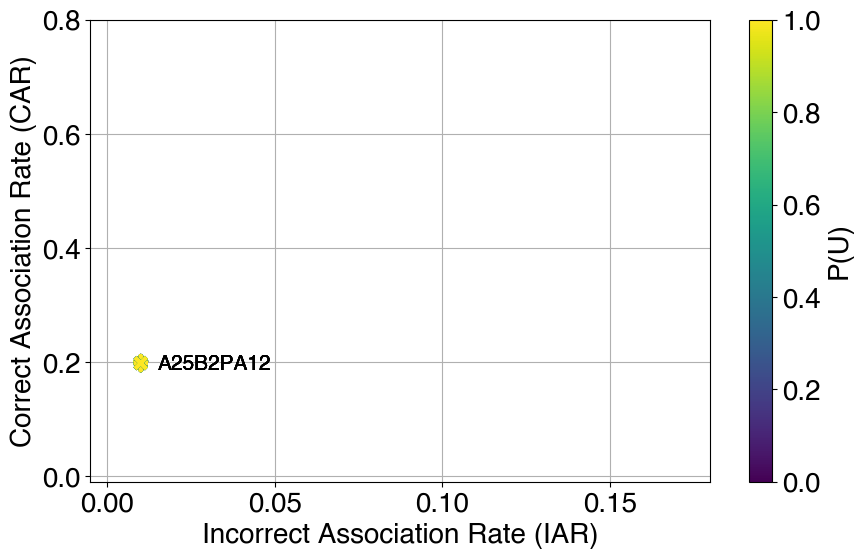

In [11]:
fig = plt.figure(figsize=(10,6))

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], 'black'] #  cycle[4], 
markers = ['x', '+', 'd', '*', 'o']
# markers = ['o', '^', 's', '*']
marker_sizes = [100, 150, 80, 100, 80]
linestyles = ['-', '--', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (1, 1))]
sims = ['a25b2pa12', 'a25b2pa12', 'a25b2pa12', 'a25b2pa12', 'a25b2pa12']
zorders = 10+np.arange(len(sims))[::-1]

for ii, loc in enumerate(sims):
    # Find ind with minimum distance from TP=1, FP=0
    fp_rates = np.array(fp_rates_all[loc])
    tp_rates = np.array(tp_rates_all[loc])
    dist = np.sqrt((fp_rates-0)**2+(tp_rates-1)**2)
    ind = np.nanargmin(dist)
    
    if loc == 'baseband':
        label = 'C'
    elif loc == 'KKO':
        label = "CK"
    elif loc == 'GBO':
        label = "CKG"
    elif loc == 'HCO':
        label = "CKGH"
    elif loc == 'DSA110':
        label = "1''"
    else:
        label = f"{loc.upper()}"
    
    plt.scatter(fp_rates, tp_rates, c=P_Us, cmap='viridis', marker=markers[ii], s=marker_sizes[ii]/1.5, lw=3, zorder=zorders[ii], label=label)
    plt.plot(fp_rates, tp_rates, marker='', lw=2, color='black', alpha=0.6, zorder=zorders[ii]-1)
    
    # Put labels next to points
    idx_pu0 = np.argmin(P_Us)  # index where P(U) is closest to 0
    plt.annotate(
        label,
        xy=(fp_rates[idx_pu0], tp_rates[idx_pu0]),
        xytext=(12, -5),
        textcoords='offset points',
        fontsize=15,
        # fontweight='bold',
        color='black',
        zorder=zorders[ii]+1
    )
plt.colorbar(label='P(U)')
plt.xlim([-0.005,0.18])
plt.ylim([-0.01,0.8])
plt.grid(zorder=1)
plt.xlabel(r'Incorrect Association Rate (IAR)') # $\rm= \frac{IA}{CA + IA}$
plt.ylabel(r'Correct Association Rate (CAR)') # $\rm= \frac{CA}{CA + IA}$

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'plots', 'paper_plot_data', 'tp_vs_fp_PU_relabel2.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 9

In [10]:
# First, load in the pre-queried galaxy catalog
fn = 'catalog_dudxmmlss_hecate_DECaL.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

TypeError: load_galaxy_catalog() got an unexpected keyword argument 'catalog_fn'

In [9]:
# Calculate which hosts are unseen for each simulation
for jj, loc in enumerate(['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']):
    print(f'Localization: {loc}')
    fn = os.path.join(os.getenv('FRB_APATH'), f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_discretize.parquet')
    digest = pd.read_parquet(fn)
    digest_unseen = sim_utils.calculate_unseen(digest, path_catalog, thresh_cross_match=2.)
    fn_out = fn.split('.parquet')[0] + '_unseen.parquet'
    digest_unseen.to_parquet(fn_out)
    print(f'Saving to {fn_out}')

Localization: a25b25pa0
Starting cross-matching (will take a minute)...
Cross-matching finished. Time elapsed: 0.448 minutes
Saving to /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/digest_a25b25pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_newoffnorm_unseen.parquet
Localization: a25b2pa12
Starting cross-matching (will take a minute)...
Cross-matching finished. Time elapsed: 0.296 minutes
Saving to /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_unseen.parquet
Localization: a15b0pa5
Starting cross-matching (will take a minute)...
Cross-matching finished. Time elapsed: 0.277 minutes
Saving to /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/digest_a15b0pa5_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_unseen.parquet
Localization: a1b1pa0
Starting cross-matching (will take a minute)...
Cross-mat

Localization: a25b25pa0


/var/folders/yv/4m3blff94q33glq2zvkdpqd40000gn/T/ipykernel_1422/3649390450.py:119: RuntimeWarning: All-NaN slice encountered
  P_Ux_bin_centers, np.nanmedian(unseen_boot_data, axis=0), yerr=np.nanstd(unseen_boot_data, axis=0),
/Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Localization: a25b2pa12
Localization: a15b0pa5
Localization: a1b1pa0
Localization: a0b0pa10


(0.0, 1.0)

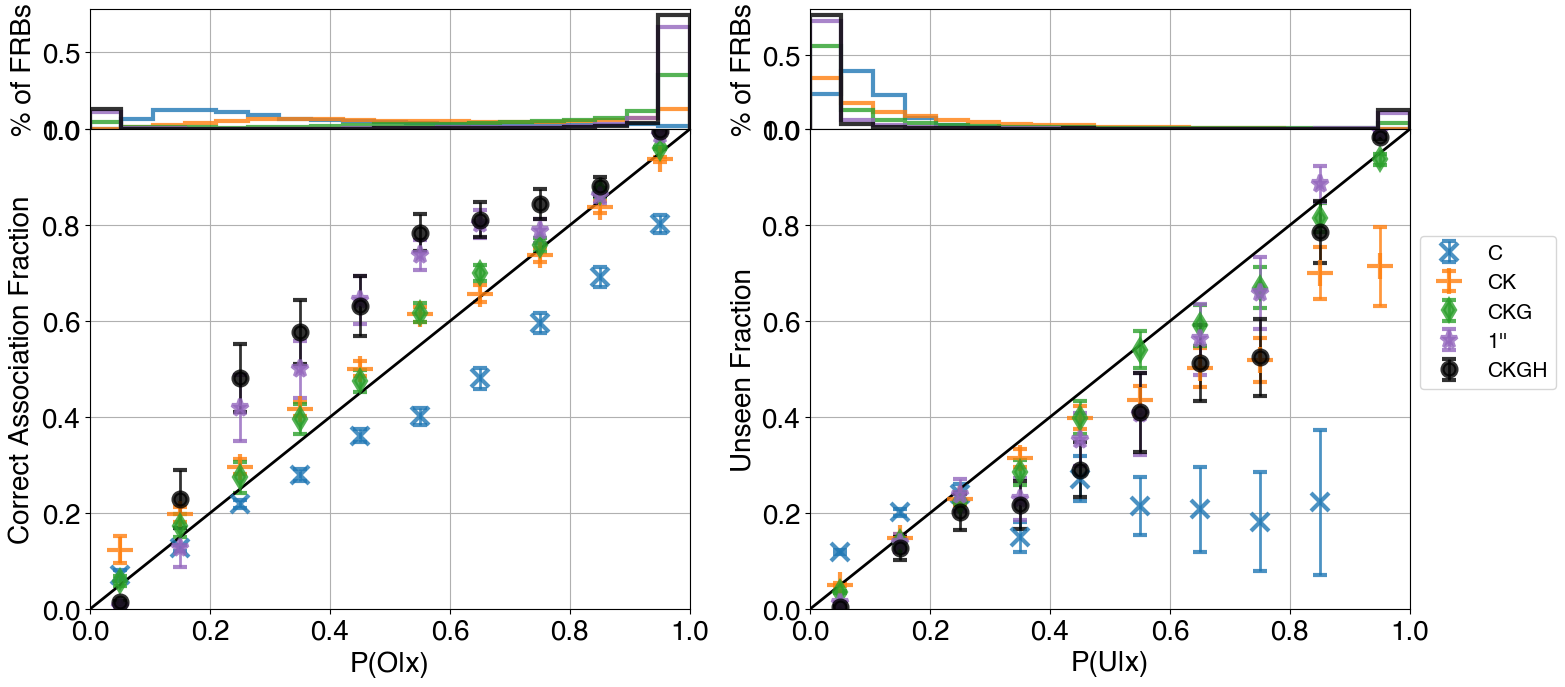

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,6))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], cycle[4], 'black', cycle[6], cycle[9]]
markers = ['x', '+', 'd', '*', 'o', '^', '>']
marker_sizes = [100, 150, 80, 100, 80, 80, 80]

sep_w = 0.1
post_POx_ax = (0., 0., 0.5, 0.8)
hist_POx_ax = (0., 0.8, 0.5, 0.2)
post_PUx_ax = (0.5+sep_w, 0., 0.5, 0.8)
hist_PUx_ax = (0.5+sep_w, 0.8, 0.5, 0.2)

ax_hist_POx = plt.axes(hist_POx_ax)
ax_post_POx = plt.axes(post_POx_ax)
ax_hist_PUx = plt.axes(hist_PUx_ax)
ax_post_PUx = plt.axes(post_PUx_ax)

for jj, loc in enumerate(['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']):
    print(f'Localization: {loc}')
    
    if loc == 'a25b25pa0':
        fn = os.path.join(os.getenv('FRB_APATH'), f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_newoffnorm_unseen.parquet')
    else:
        fn = os.path.join(os.getenv('FRB_APATH'), f'digest_{loc}_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_unseen.parquet')
    digest = pd.read_parquet(fn)
    
    # ----------------------------------------------------
    # PLOT P(O|x) POSTERIORS
    # ----------------------------------------------------
    bins = np.linspace(0,1,20)
    weights = np.ones_like(digest['P_Ox']) / len(digest)
    _ = ax_hist_POx.hist(digest['P_Ox'], bins=bins, weights=weights, density=False, histtype='step', lw=3, color=colors[jj], alpha=0.8)
    ax_hist_POx.set_ylabel('% of FRBs')
    ax_hist_POx.set_xlim([0.,1.])
    ax_hist_POx.grid(zorder=20)
    ax_hist_POx.set_xticklabels([])

    # Bootstrap to get errors (Increased N to 200 for stability)
    N_boot = 200
    tp_boot_data = []
    P_Ox_bin_edges = np.arange(0, 1.1, 0.1)
    P_Ox_bin_centers = (P_Ox_bin_edges[:-1] + P_Ox_bin_edges[1:]) / 2.

    for kk in range(N_boot):
        # Sample WITH replacement, keeping the total row count identical
        digest_boot = digest.sample(frac=1.0, replace=True)

        tp_fraction = []
        for ii in range(len(P_Ox_bin_edges)-1):
            P_Ox_start_bin = P_Ox_bin_edges[ii]
            P_Ox_end_bin = P_Ox_bin_edges[ii+1]
            in_bin = ((digest_boot['P_Ox'] >= P_Ox_start_bin) & (digest_boot['P_Ox'] <= P_Ox_end_bin)).values
            digest_in_bin = digest_boot[in_bin]
            digest_tp = digest_in_bin[digest_in_bin['correct_association']]
            
            if len(digest_in_bin) < 1:
                tp_frac = np.nan
            else:
                tp_frac = len(digest_tp) / len(digest_in_bin)
            tp_fraction.append(tp_frac)
            
        tp_boot_data.append(tp_fraction)
        
    if loc == 'a25b25pa0': label = 'C'
    elif loc == 'a25b2pa12': label = "CK"
    elif loc == 'a15b0pa5': label = "CKG"
    elif loc == 'a1b1pa0': label = "1''"
    elif loc == 'a0b0pa10': label = "CKGH"
        
    # Plot points using standard deviation directly (No multiplier required)
    ax_post_POx.errorbar(
        P_Ox_bin_centers, np.nanmedian(tp_boot_data, axis=0), yerr=np.nanstd(tp_boot_data, axis=0), 
        capsize=5, elinewidth=2, mew=3, markersize=marker_sizes[jj]/8, 
        color=colors[jj], marker=markers[jj], linestyle="None", alpha=0.8, label=label,
    ) 

    # ----------------------------------------------------
    # PLOT P(U|x) POSTERIORS
    # ----------------------------------------------------
    bins = np.linspace(0,1,20)
    weights = np.ones_like(digest['P_Ux']) / len(digest)
    _ = ax_hist_PUx.hist(digest['P_Ux'], bins=bins, weights=weights, density=False, histtype='step', lw=3, color=colors[jj], alpha=0.8)
    ax_hist_PUx.set_ylabel('% of FRBs')
    ax_hist_PUx.set_xlim([0.,1.])
    ax_hist_PUx.grid(zorder=20)
    ax_hist_PUx.set_xticklabels([])

    # Bootstrap to get errors
    unseen_boot_data = []
    P_Ux_bin_edges = np.arange(0., 1.1, 0.1)
    P_Ux_bin_centers = (P_Ux_bin_edges[:-1] + P_Ux_bin_edges[1:]) / 2.

    for kk in range(N_boot):
        # Sample WITH replacement, keeping the total row count identical
        digest_boot = digest.sample(frac=1.0, replace=True)

        unseen_fraction = []
        for ii in range(len(P_Ux_bin_edges)-1):
            P_Ux_start_bin = P_Ux_bin_edges[ii]
            P_Ux_end_bin = P_Ux_bin_edges[ii+1]
            in_bin = ((digest_boot['P_Ux'] >= P_Ux_start_bin) & (digest_boot['P_Ux'] <= P_Ux_end_bin)).values
            digest_in_bin = digest_boot[in_bin]
            digest_unseen = digest_in_bin[digest_in_bin['unseen']]
            
            if len(digest_in_bin) < 1:
                unseen_frac = np.nan
            else:
                unseen_frac = len(digest_unseen) / len(digest_in_bin)
            unseen_fraction.append(unseen_frac)
            
        unseen_boot_data.append(unseen_fraction)
        
    # Plot points using standard deviation directly (No multiplier required)   
    ax_post_PUx.errorbar(
        P_Ux_bin_centers, np.nanmedian(unseen_boot_data, axis=0), yerr=np.nanstd(unseen_boot_data, axis=0), 
        capsize=5, elinewidth=2, mew=3, markersize=marker_sizes[jj]/8, 
        color=colors[jj], marker=markers[jj], linestyle="None", alpha=0.8, label=label,
    ) 
    
ax_post_PUx.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), lw=2, color='black')
ax_post_PUx.set_xlabel('P(U|x)')
ax_post_PUx.set_ylabel('Unseen Fraction')
ax_post_PUx.legend(fontsize=15)
ax_post_PUx.grid(zorder=20)
ax_post_PUx.set_ylim([0.,1.])
ax_post_PUx.set_xlim([0.,1.])
ax_post_PUx.legend(fontsize=15, bbox_to_anchor=[1., 0.8])

ax_post_POx.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), lw=2, color='black')
ax_post_POx.set_xlabel('P(O|x)')
ax_post_POx.set_ylabel('Correct Association Fraction')
ax_post_POx.grid(zorder=20)
ax_post_POx.set_ylim([0.,1.])
ax_post_POx.set_xlim([0.,1.])

# plot_fn = os.path.join(os.getenv('FRB_APATH'), 'paper_figures', 'posterior_calibration_exp_redo_relabel.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")


In [33]:
# ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
fn = os.path.join(os.getenv('FRB_APATH'), f'digest_a25b25pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_unseen.parquet')
digest = pd.read_parquet(fn)

In [34]:
# ['a25b25pa0', 'a25b2pa12', 'a15b0pa5', 'a1b1pa0', 'a0b0pa10']
fn = os.path.join(os.getenv('FRB_APATH'), f'digest_a25b25pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_newgalprune_unseen.parquet')
digest_newgalprune = pd.read_parquet(fn)

In [35]:
digest

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,dec_cand,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association,unseen
0,34.711156,-5.327000,34.694600,-5.312589,37484700738035608,0.856394,20.936630,0.715546,78.824441,0,...,-5.322569,0.764380,19.793200,8796112702146051,0.012574,0.000150,0.369223,0.117576,False,False
1,37.160329,-3.655108,37.164400,-3.668060,8796113267725806,0.503261,21.707293,0.673500,48.864075,1,...,-3.661424,0.936604,19.342678,8796113267725948,0.005995,0.000160,0.379766,0.237530,False,False
2,37.487562,-5.356904,37.497276,-5.359696,8796112702865907,0.508403,19.605140,0.735599,36.241808,2,...,-5.359813,0.735599,19.605140,8796112702865907,0.004036,0.000087,0.209309,0.357285,True,False
3,35.229074,-5.526409,35.235658,-5.527110,37489781684340048,0.371386,22.757252,0.537344,23.727958,3,...,-5.526932,0.598287,21.288452,8796112608300012,0.001422,0.000173,0.096186,0.234463,False,False
4,4.787604,29.941555,4.786000,29.941987,8796125508273408,2.316953,18.302269,0.996600,5.240161,4,...,29.942532,0.996600,18.302269,8796125508273408,0.013479,0.000249,0.694783,0.124134,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,36.094304,-4.934195,36.090889,-4.940372,37489244813400741,0.198079,27.180218,0.283836,25.385930,9995,...,-4.944841,1.065903,20.362122,8796112796586882,0.003731,0.000071,0.073209,0.165050,False,True
9996,36.396548,-5.807073,36.399229,-5.799793,8796112514582300,2.839517,19.410067,1.728555,27.912050,9996,...,-5.802747,1.054093,18.411608,8796112514582299,0.003121,0.000202,0.358535,0.340569,False,False
9997,35.103902,-4.524862,35.098203,-4.521281,8796112984608084,0.952661,20.341639,1.132291,24.173515,9997,...,-4.521020,1.044454,18.810524,8796112984542487,0.024749,0.000139,0.393673,0.068682,False,False
9998,38.024224,-5.563481,38.024195,-5.556637,8796112609020131,0.996515,19.840750,1.774440,24.636605,9998,...,-5.564934,2.708694,18.261482,8796112609019852,0.055634,0.000223,0.522492,0.025218,False,False


In [36]:
digest_newgalprune

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,dec_cand,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association,unseen
0,34.711156,-5.327000,34.694600,-5.312589,37484700738035608,0.856394,20.936630,0.715546,78.824441,0,...,-5.322569,0.764380,19.793200,8796112702146051,0.104932,0.000150,0.374913,0.108990,False,False
1,37.160329,-3.655108,37.164400,-3.668060,8796113267725806,0.503261,21.707293,0.673500,48.864075,1,...,-3.661424,0.936604,19.342678,8796113267725948,0.137433,0.000160,0.447501,0.104706,False,False
2,37.487562,-5.356904,37.497276,-5.359696,8796112702865907,0.508403,19.605140,0.735599,36.241808,2,...,-5.359813,0.735599,19.605140,8796112702865907,0.101235,0.000087,0.275692,0.157364,True,False
3,35.229074,-5.526409,35.235658,-5.527110,37489781684340048,0.371386,22.757252,0.537344,23.727958,3,...,-5.526932,0.598287,21.288452,8796112608300012,0.004061,0.000173,0.101875,0.201991,False,False
4,4.787604,29.941555,4.786000,29.941987,8796125508273408,2.316953,18.302269,0.996600,5.240161,4,...,29.942532,0.996600,18.302269,8796125508273408,0.315718,0.000249,0.768994,0.030901,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,36.094304,-4.934195,36.090889,-4.940372,37489244813400741,0.198079,27.180218,0.283836,25.385930,9995,...,-4.944841,1.065903,20.362122,8796112796586882,0.032944,0.000071,0.075445,0.142922,False,True
9995,36.396548,-5.807073,36.399229,-5.799793,8796112514582300,2.839517,19.410067,1.728555,27.912050,9996,...,-5.802747,1.054093,18.411608,8796112514582299,0.012707,0.000202,0.423985,0.221252,False,False
9996,35.103902,-4.524862,35.098203,-4.521281,8796112984608084,0.952661,20.341639,1.132291,24.173515,9997,...,-4.521020,1.044454,18.810524,8796112984542487,0.138007,0.000139,0.382990,0.095442,False,False
9997,38.024224,-5.563481,38.024195,-5.556637,8796112609020131,0.996515,19.840750,1.774440,24.636605,9998,...,-5.564934,2.708694,18.261482,8796112609019852,0.247103,0.000223,0.514141,0.041934,False,False


In [108]:
# Load in the combined host catalog
combined_catalog_fn = os.path.join(os.getenv('FRB_APATH'), 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet')
combined_catalog = pd.read_parquet(combined_catalog_fn)

In [109]:
import numpy as np
import pandas as pd

# 1. Get unique IDs from digest to minimize search space
digest_ids = digest["host_ID"].unique()

# 2. Build a high-speed lookup dictionary from combined_catalog
id_to_source = {}
id_columns = ["DECaL_ID", "HSC_ID", "SDSS_PHOTID"]

for col in id_columns:
    # Get valid, non-null IDs from this column that exist in digest
    matched_ids = combined_catalog.loc[
        combined_catalog[col].isin(digest_ids), col
    ].dropna()

    # Bulk-add them to the dictionary pointing to the current column name
    id_to_source.update({id_val: col for id_val in matched_ids})

# 3. Instantly map the dictionary to create your new column
digest["matched_column"] = digest["host_ID"].map(id_to_source)

# Optional: Fill IDs that didn't find a match anywhere
digest["matched_column"] = digest["matched_column"].fillna("No Match")

In [37]:
P_Ux_start_bin = 0.5
P_Ux_end_bin = 0.6
in_bin = ((digest['P_Ux'] >= P_Ux_start_bin) & (digest['P_Ux'] <= P_Ux_end_bin)).values
digest[in_bin]

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,dec_cand,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association,unseen
179,164.678075,-2.570609,164.678796,-2.554415,8796113772610748,2.502161,17.790176,2.745448,58.356697,179,...,-2.555109,2.745448,17.790176,8796113772610748,0.012726,0.000021,0.250355,0.554571,True,False
329,34.604570,-6.672907,34.589909,-6.669616,8796112138605872,0.302677,21.121355,0.897367,53.745077,329,...,-6.678009,0.605524,19.426777,8796112138605635,0.001533,0.000098,0.133743,0.536459,False,False
417,36.778739,-3.852066,36.783707,-3.838427,8796113267590052,0.401638,19.653625,0.944728,52.244821,417,...,-3.838367,0.944728,19.653625,8796113267590052,0.001601,0.000029,0.042441,0.557634,True,False
451,35.251624,-4.645068,35.251332,-4.647658,37489803159171489,0.355418,26.147469,0.364639,9.382196,451,...,-4.650380,0.626442,20.386340,8796112890502254,0.001064,0.000048,0.046862,0.551446,False,True
530,34.995406,-5.636861,34.988336,-5.641191,37490056562231876,0.604077,22.615065,0.548509,29.742043,530,...,-5.636986,0.309805,20.953000,8796112514260394,0.000669,0.000067,0.042290,0.564445,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9699,36.544770,-3.641628,36.546285,-3.641711,38558653015419216,0.306787,23.756298,0.500453,5.452340,9699,...,-3.631993,0.799213,19.382288,8796113267530662,0.003962,0.000039,0.138136,0.532317,False,True
9711,247.311175,40.886913,247.307436,40.884035,8797228456607918,1.705393,18.649847,1.428602,14.524506,9711,...,40.884506,1.428602,18.649847,8797228456607918,0.001233,0.000220,0.241697,0.535383,True,False
9774,37.175133,-4.967651,37.169264,-4.969675,37493917737841295,0.921719,23.919449,0.334566,22.274151,9774,...,-4.960550,0.849011,21.318117,8796112796914215,0.000662,0.000131,0.075736,0.522332,False,True
9796,35.209770,-4.469436,35.207307,-4.459005,38554237789041306,0.286644,26.677465,0.396544,38.578525,9796,...,-4.462507,1.729969,20.163336,8796112984609960,0.000845,0.000121,0.089813,0.527772,False,True


In [51]:
digest_newgalprune.iloc[[167]]

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,dec_cand,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association,unseen
179,164.678075,-2.570609,164.678796,-2.554415,8796113772610748,2.502161,17.790176,2.745448,58.356697,179,...,-2.555109,2.745448,17.790176,8796113772610748,0.533021,0.000021,0.462269,0.182617,True,False


In [49]:
digest.iloc[[179]]

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,ra_cand,dec_cand,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association
179,164.678783,-2.554478,164.678796,-2.554415,8796113772610748,2.502161,17.790176,2.745448,0.233254,179,...,164.678754,-2.555109,2.745448,17.790176,8796113772610748,0.094916,0.014949,0.999185,0.000815,True


In [44]:
len(digest[in_bin][digest[in_bin]['unseen']])/len(digest[in_bin])

0.20930232558139536

In [43]:
len(digest_newgalprune[in_bin][digest_newgalprune[in_bin]['unseen']])/len(digest_newgalprune[in_bin])

0.20930232558139536

In [39]:
P_Ux_start_bin = 0.5
P_Ux_end_bin = 0.6
in_bin = ((digest_newgalprune['P_Ux'] >= P_Ux_start_bin) & (digest_newgalprune['P_Ux'] <= P_Ux_end_bin)).values
digest_newgalprune[in_bin]

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,dec_cand,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association,unseen
13,231.169575,20.692232,231.180792,20.689131,8796122403898380,4.384581,17.645916,6.300354,39.393155,13,...,20.689521,6.300354,17.645916,8796122403898380,0.017641,5.899720e-05,0.251955,0.592272,True,False
148,183.039628,13.184069,183.029975,13.174664,8796119682581680,0.489817,17.510763,1.023114,47.864845,148,...,13.174530,1.023114,17.510763,8796119682581680,0.021812,3.955135e-05,0.307186,0.543499,True,False
223,34.930629,-7.212915,34.919489,-7.200572,8796111951237352,0.345314,20.682076,0.641914,59.644609,223,...,-7.200344,6.841686,15.104958,8796111951237196,0.824299,2.061500e-06,0.335560,0.549848,False,False
474,34.055427,-5.293144,34.045915,-5.303747,8796112701949792,0.269699,21.648964,0.796301,51.181298,474,...,-5.316049,10.630520,15.172526,8796112701949354,0.818423,3.187802e-07,0.097199,0.577880,False,False
596,34.037043,-5.287467,34.040496,-5.284699,8796112701950267,0.570666,21.766443,0.334028,15.891477,596,...,-5.293081,0.207700,20.853426,8796112701949960,0.001258,1.674738e-04,0.072937,0.536821,False,False
1068,35.387977,-3.754577,35.392994,-3.743409,8796113267265677,0.569230,19.501818,0.432292,44.060371,1068,...,-3.743445,0.432292,19.501818,8796113267265677,0.004706,5.348761e-05,0.085678,0.519585,True,False
1138,35.252700,-4.540016,35.252008,-4.533199,8796112984607633,0.688571,20.267889,1.690933,24.667684,1138,...,-4.548603,1.718088,18.316732,8796112984607204,0.007558,3.320134e-05,0.114703,0.512549,False,False
1317,35.574682,-6.260184,35.567705,-6.270722,8796112326560980,0.151930,20.867386,0.661605,45.417924,1317,...,-6.238800,3.761302,14.450748,8796112326561746,0.783976,5.564670e-07,0.172161,0.592791,False,False
1356,33.805440,-3.230143,33.810271,-3.228613,8796113455353686,0.380227,21.161924,0.506081,18.216091,1356,...,-3.217117,2.665871,18.374720,8796113455289143,0.018642,2.087454e-05,0.108130,0.591121,False,False
1405,35.678702,-5.540659,35.688802,-5.539030,37489506806430832,0.456535,24.765282,0.354003,36.662344,1405,...,-5.527130,1.680734,18.793613,8796112608430790,0.036308,1.484189e-05,0.084622,0.535242,False,True


In [106]:
P_Ux_start_bin = 0.5
P_Ux_end_bin = 0.6
in_bin = ((digest['P_Ux'] >= P_Ux_start_bin) & (digest['P_Ux'] <= P_Ux_end_bin)).values
# Count the occurrences of each category (including 'No Match')
counts = digest[in_bin]['matched_column'].value_counts()
print(counts)
print(f"{np.nanmean(digest[in_bin]['ang_size_host']):.2f} \t {np.nanmean(digest[in_bin]['ang_size_cand']):.2f}")

KeyError: 'matched_column'

In [134]:
digest[in_bin][~digest[in_bin]['unseen']]

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association,unseen,matched_column
179,164.678075,-2.570609,164.678796,-2.554415,8796113772610748,2.502161,17.790176,2.745448,58.356697,179,...,2.745448,17.790176,8796113772610748,0.012726,0.000021,0.250355,0.554571,True,False,DECaL_ID
329,34.604570,-6.672907,34.589909,-6.669616,8796112138605872,0.302677,21.121355,0.897367,53.745077,329,...,0.605524,19.426777,8796112138605635,0.001533,0.000098,0.133743,0.536459,False,False,DECaL_ID
417,36.778739,-3.852066,36.783707,-3.838427,8796113267590052,0.401638,19.653625,0.944728,52.244821,417,...,0.944728,19.653625,8796113267590052,0.001601,0.000029,0.042441,0.557634,True,False,DECaL_ID
530,34.995406,-5.636861,34.988336,-5.641191,37490056562231876,0.604077,22.615065,0.548509,29.742043,530,...,0.309805,20.953000,8796112514260394,0.000669,0.000067,0.042290,0.564445,False,False,HSC_ID
550,36.323216,-4.287814,36.307526,-4.283586,8796113079044810,0.475897,21.196724,0.344881,58.348421,550,...,2.005104,17.935686,8796113079045091,0.007713,0.000035,0.227920,0.510839,False,False,DECaL_ID
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9356,36.349609,-4.288058,36.359507,-4.294840,38553280011327273,0.483806,22.711063,0.900986,43.113704,9356,...,1.031498,20.102865,8796113079044613,0.000655,0.000236,0.129042,0.500105,False,False,HSC_ID
9487,352.754878,21.343061,352.736411,21.344115,8796122610011187,0.659256,18.888830,1.036946,62.040416,9487,...,1.306879,19.289494,8796122610011044,0.002298,0.000056,0.116334,0.545130,False,False,DECaL_ID
9657,34.409671,-5.247161,34.416884,-5.249670,8796112702082348,1.994514,21.358513,1.195170,27.389580,9657,...,1.195170,21.358513,8796112702082348,0.000554,0.000140,0.068336,0.529200,True,False,DECaL_ID
9672,35.749765,-4.512058,35.740212,-4.507669,8796112984739379,0.663079,20.054640,0.689882,37.748240,9672,...,1.694466,19.455341,8796112984739186,0.001114,0.000171,0.184989,0.581636,False,False,DECaL_ID


In [105]:
len(digest[in_bin])

NameError: name 'in_bin' is not defined

## Figure 10

In [12]:
# If you want to make images from HSC survey, input your HSC SSP CAS credentials
os.environ["HSC_SSP_CAS_USER"] = "<username>"
os.environ["HSC_SSP_CAS_PASSWORD"] = "<password>"

In [6]:
# fn = os.path.join(os.getenv('FRB_APATH'), f'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_origsim.parquet')
fn = os.path.join(os.getenv('FRB_APATH'), f'digest_a25b25pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_unseen.parquet')
digest = pd.read_parquet(fn)

In [7]:
# fn = os.path.join(os.getenv('FRB_APATH'), f'full_path_results_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000_origsim.parquet')
fn = os.path.join(os.getenv('FRB_APATH'), f'full_path_results_a25b25pa0_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL_10000.parquet')
sim_results = pd.read_parquet(fn)

In [13]:
digest[digest.FRB_ID == 179]

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,dec_cand,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association,unseen
179,164.678075,-2.570609,164.678796,-2.554415,8796113772610748,2.502161,17.790176,2.745448,58.356697,179,...,-2.555109,2.745448,17.790176,8796113772610748,0.012726,0.000021,0.250355,0.554571,True,False


In [10]:
sim_results[sim_results.iFRB == 179]

,ra,dec,ang_size,mag,ID,sep,P_O,p_xO,P_Ox,P_Ux,gal_ID,iFRB
158659,164.678754,-2.555109,2.745448,17.790176,8796113772610748,55.854857,0.012726,2.128415e-05,2.503547e-01,0.554571,497,179
158660,164.683218,-2.575284,0.226566,21.600813,8796113772610402,25.007399,0.000241,1.544938e-04,3.444049e-02,0.554571,442,179
158661,164.675254,-2.564415,0.921569,21.895845,8796113772610589,24.497289,0.000184,1.575682e-04,2.676694e-02,0.554571,468,179
158662,164.677745,-2.577047,0.313544,22.478054,8796113772610363,23.207090,0.000109,1.655972e-04,1.669384e-02,0.554571,438,179
158663,164.671856,-2.563422,0.213003,22.341652,8796113772610632,34.200183,0.000123,9.995850e-05,1.136770e-02,0.554571,152,179
...,...,...,...,...,...,...,...,...,...,...,...,...
159290,164.736029,-2.607811,0.393022,24.780860,8796113772609874,247.744690,0.000017,1.217223e-25,1.873901e-24,0.554571,345,179
159291,164.701147,-2.635593,0.245487,24.598316,8796113678241997,248.220116,0.000019,1.002508e-25,1.772391e-24,0.554571,281,179
159292,164.667100,-2.502119,0.507251,23.933050,8796113772611767,249.704533,0.000032,5.614907e-26,1.669049e-24,0.554571,276,179
159293,164.746288,-2.559255,0.345839,24.704466,8796113772610683,248.704488,0.000018,8.297895e-26,1.353315e-24,0.554571,488,179


In [20]:
ra_loc

179    164.678075
Name: ra_loc, dtype: float64

In [21]:
# Grab necessary info, index is the FRB number in the digest
# ii = 9197
ii = 179
include_legend = False

digest_frb = digest[digest.FRB_ID == 179]
ra_true_host = digest_frb['ra_host'].item()
dec_true_host = digest_frb['dec_host'].item()
mag_true_host = digest_frb['mag_host'].item()
angsize_host = digest_frb['ang_size_host'].item()
print("True Host: RA={:.4f}\tDEC={:.4f}\tmag={:.2f}".format(ra_true_host, dec_true_host, mag_true_host))
results = sim_results[sim_results.iFRB == ii]
results_best_cand = results.iloc[0:1]
results_second_cand = results.iloc[1:2]
ra_best_cand = results_best_cand['ra'].item()
dec_best_cand = results_best_cand['dec'].item()
mag_best_cand = results_best_cand['mag'].item()
angsize_cand = results_best_cand['ang_size'].item()
POx_best_cand = results_best_cand['P_Ox'].item()
POx_second_cand = results_second_cand['P_Ox'].item()
mag_second_cand = results_second_cand['mag'].item()
PUx = results_best_cand['P_Ux'].item()
print("Best Candidate: RA={:.4f}\tDEC={:.4f}\tmag={:.2f}\tP(O|x)={:.2f}".format(ra_best_cand, dec_best_cand, mag_best_cand, POx_best_cand))
print("Second Candidate: mag={:.2f}\tP(O|x)={:.2f}\tP(U|x)={:.2f}".format(mag_second_cand, POx_second_cand, PUx))
ra_frb = digest_frb['true_ra'].item()
dec_frb = digest_frb['true_dec'].item()
print("FRB: RA={:.4f}\tDEC={:.4f}".format(ra_frb, dec_frb))
ra_loc = digest_frb['ra_loc'].item()
dec_loc = digest_frb['dec_loc'].item()
a_err = digest_frb['a'].item() / 3600.
b_err = digest_frb['b'].item() / 3600.
print("Localization: RA={:.4f}\tDEC={:.4f}\ta={:.2f}\tb={:.2f}".format(ra_loc, dec_loc, a_err*3600, b_err*3600))
theta = digest_frb['PA'].item()

True Host: RA=164.6788	DEC=-2.5551	mag=17.79
Best Candidate: RA=164.6788	DEC=-2.5551	mag=17.79	P(O|x)=0.25
Second Candidate: mag=21.60	P(O|x)=0.03	P(U|x)=0.55
FRB: RA=164.6788	DEC=-2.5544
Localization: RA=164.6781	DEC=-2.5706	a=25.00	b=25.00


In [24]:
df_test = pd.read_parquet('/Users/bandersen/Documents/CHIME/notebooks/path_simulations/check.parquet')

Get nice DECaL PNG of 512 pixels with conversion scale of 1.0986328125 arcseconds per pixel
Get available fits from DECaL at given location
Convert color png into fits
Calculate an optimal WCS to share between all the fits
Generate empty datacube, reprojecting each color to the new WCS
Write out collapsed version of cube for aplpy plotting purposes
Save the reprojected fits into a PNG, also for aplpy plotting purposes
Make plot!


164.67807450665805 -2.5706089814784097 9.375 0.15625
Remove temporary plotting files: rgb_2d.fits, rgb.png


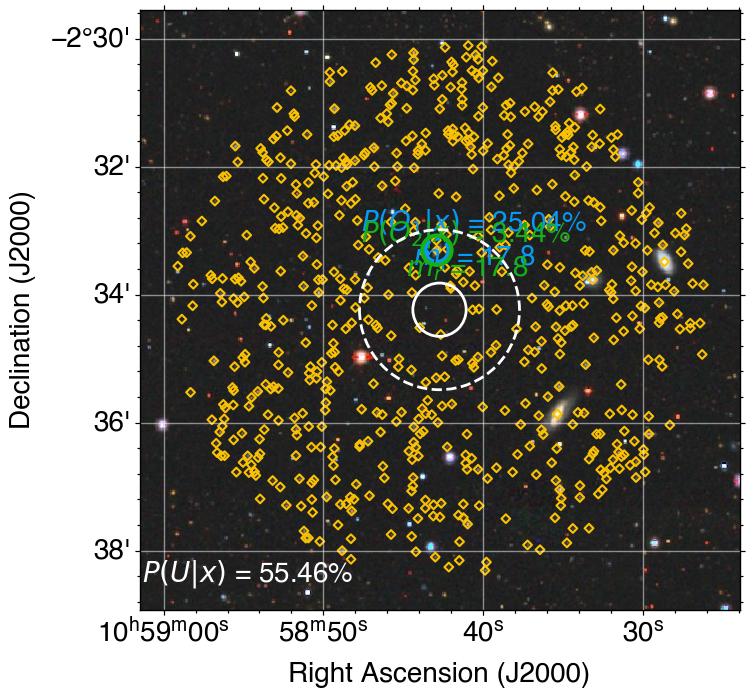

In [26]:
# Pick which survey to plot
survey_str = 'DECaL' # Can be: 'HSC', 'DECaL', 'Pan-STARRS'
size_arcmin = np.nanmax([3.*a_err, 3.*b_err]) * 60. * 2.5 * 3.

sup_fig = plt.figure(figsize=(6, 6))
axes = [0., 0., 1., 1.]

sim_utils.plot_color_image(
    ra_true_host, dec_true_host,
    mag_true_host, angsize_host,
    ra_best_cand, dec_best_cand,
    mag_best_cand, angsize_cand,
    POx_best_cand, POx_second_cand, PUx,
    ra_loc, dec_loc,
    a_err, b_err,
    theta,
    sup_fig, axes, include_legend,
    size_arcmin=size_arcmin, filt="gri", 
    survey_str=survey_str, outfile=None, scale=99.9,
    all_cands=results,
)

In [24]:
size_arcmin

np.float64(9.375)

In [32]:
results

,ra,dec,ang_size,mag,ID,sep,P_O,p_xO,P_Ox,P_Ux,gal_ID,iFRB
158659,164.675126,-2.565042,0.377264,23.004719,8796113772610590,22.673735,0.001336,1.688654e-04,6.790366e-02,0.180527,469,179
158660,164.677745,-2.577047,0.313544,22.478054,8796113772610363,23.207090,0.001336,1.655972e-04,6.658948e-02,0.180527,438,179
158661,164.675254,-2.564415,0.921569,21.895845,8796113772610589,24.497289,0.001336,1.575682e-04,6.336087e-02,0.180527,468,179
158662,164.683218,-2.575284,0.226566,21.600813,8796113772610402,25.007399,0.001336,1.544938e-04,6.212460e-02,0.180527,442,179
158663,164.685255,-2.566143,0.479614,23.768023,8796113772610563,30.419436,0.001336,1.215269e-04,4.886804e-02,0.180527,465,179
...,...,...,...,...,...,...,...,...,...,...,...,...
159290,164.746288,-2.559255,0.345839,24.704466,8796113772610683,248.704488,0.001336,8.297895e-26,3.336726e-23,0.180527,488,179
159291,164.644864,-2.631320,0.344332,21.725220,8796113678242065,249.065934,0.001336,7.185236e-26,2.889307e-23,0.180527,4,179
159292,164.670578,-2.501806,0.264981,25.058805,8796113772611773,249.155316,0.001336,6.914229e-26,2.780330e-23,0.180527,277,179
159293,164.667100,-2.502119,0.507251,23.933050,8796113772611767,249.704533,0.001336,5.614907e-26,2.257850e-23,0.180527,276,179


In [76]:
 size_arcmin * 60. / 2.

np.float64(281.25)

In [99]:
PU = 0.15
p_xU = 1/(2 * size_arcmin * 60. / 2.2)**2 * 1.2 # 1/(np.pi * (size_arcmin * 60. / 2.2)**2) 
px = PU * p_xU + np.nansum([results.iloc[ii]['P_O'] * results.iloc[ii]['p_xO'] for ii in range(len(results))])
px

np.float64(3.4119591677227795e-06)

In [100]:
ii = 0
P_Ox = results.iloc[ii]['P_O'] * results.iloc[ii]['p_xO'] / px
P_Ux = PU * p_xU / px
print(f"{P_Ox:.3f}, {P_Ux:.3f}")

0.066, 0.202


## Figure 11

In [ ]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [cycle[0], cycle[1], cycle[2], cycle[4], 'black']
markers = ['x', '+', 'd', '*', 'o']
marker_sizes = [100, 150, 80, 100, 80]
linestyles = ['-', '--', '-.', (0, (3, 1, 1, 1, 1, 1)), (0, (1, 1))]

# (left, bottom, width, height)
width = 0.5
sep_w = 0.15
height = 0.5
sep_h = 0.15
inverse_hist_ax = (0., height+sep_h, width, height)
identical_hist_ax = (width+sep_w, height+sep_h, width, height)
inverse_fract_ax = (0., 0., width, height)
identical_fract_ax = (width+sep_w, 0., width, height)

fig = plt.figure(figsize=(12,8))
sim_name = 'kko'
P_Ox_thresh = 0.8
fig.suptitle('P(O|x) > {0:d}% Threshold'.format(int(P_Ox_thresh*100)), y=1.25, fontsize=25)
bins = np.linspace(11, 28, 20)

##################################################################################################
############################### Plotting Inverse Histogram #######################################
##################################################################################################

run_name = 'exp'
# plotting_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', '{}_sim_{}'.format(sim_name, run_name), f'plot_data_{survey_str}_centroidfix_zinfo.parquet')
plotting_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'SIMULATIONS_FINAL', '{}_sim_{}'.format(sim_name, run_name), f'plot_data_DECaL_zinfo_DECaLhost_hecatecut.parquet')
df = pandas.read_parquet(plotting_fn)
Nfrbs = float(len(df))
print("Inverse Prior")

ax = plt.axes(inverse_hist_ax)

# Get true positives
max_ang_size = np.maximum.reduce([df['ang_size_cand'], df['half_light_host']], axis=0)
match_criteria_selected = (df['sep_best_host'] < 1.5*max_ang_size) & (df['P_Ox'] > P_Ox_thresh)# & (df['mag_host'] > 14.5) & (df['mag_host'] < 24.)
df_selected = df[match_criteria_selected]
print("True Positives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, _, _ = plt.hist(mag_hosts, density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[1], alpha=0.7, bins=bins, zorder=5, hatch='//', fill='False', histtype='step', label='CA True Host')
plt.hist(mag_cands, density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[0], alpha=0.7, bins=bins, zorder=5, hatch='\\\\', histtype='step', label='CA Best Candidate')

# Get false positives
max_ang_size = np.maximum.reduce([df['ang_size_cand'], df['half_light_host']], axis=0)
match_criteria_selected = (df['sep_best_host'] > 1.5*max_ang_size) & (df['P_Ox'] > P_Ox_thresh) # & (df['mag_host'] > 14.) & (df['mag_host'] < 24.)
df_selected = df[match_criteria_selected]
print("False Positives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, _, _ = plt.hist(mag_hosts, density=False, weights=weights,  color=cycle[1], alpha=0.7, bins=bins, zorder=5, label='IA True Host')
plt.hist(mag_cands, density=False, weights=weights,  color=cycle[0], alpha=0.7, bins=bins, zorder=5, label='IA Best Candidate')

# Get negatives
match_criteria_selected = (df['P_Ox'] < P_Ox_thresh) # & (df['mag_host'] > 14.) & (df['mag_host'] < 24.)
df_selected = df[match_criteria_selected]
print("Negatives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, bins, _ = plt.hist(mag_hosts, density=False, weights=weights, facecolor='None', lw=2.5, edgecolor=cycle[2], alpha=0.7, bins=bins, zorder=5, histtype='step', label='NA')
# _, bins, _ = plt.hist(mag_hosts, color=cycle[2], alpha=0.5, bins=20, zorder=5, label='TN + FN')

plt.title('Inverse Prior: CK')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
# plt.yscale('log')
# plt.legend(fontsize=15)
handles, labels = ax.get_legend_handles_labels()
plt.grid(zorder=1)
plt.xlim([11,28])

print()
##################################################################################################
############################### Plotting Identical Histogram #####################################
##################################################################################################

run_name = 'identical'
# plotting_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', '{}_sim_{}'.format(sim_name, run_name), f'plot_data_{survey_str}_centroidfix_zinfo.parquet')
plotting_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'SIMULATIONS_FINAL', '{}_sim_{}'.format(sim_name, run_name), f'plot_data_DECaL_zinfo_DECaLhost_hecatecut.parquet')
df = pandas.read_parquet(plotting_fn)
Nfrbs = float(len(df))
print("Identical Prior")

ax = plt.axes(identical_hist_ax)

# Get true positives
max_ang_size = np.maximum.reduce([df['ang_size_cand'], df['half_light_host']], axis=0)
match_criteria_selected = (df['sep_best_host'] < 2.*max_ang_size) & (df['P_Ox'] > P_Ox_thresh)# & (df['mag_host'] > 14.5) & (df['mag_host'] < 24.)
df_selected = df[match_criteria_selected]
print("True Positives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, _, _ = plt.hist(mag_hosts, density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[1], alpha=0.7, bins=bins, zorder=5, hatch='//', fill='False', histtype='step', label='CA True Host')
plt.hist(mag_cands, density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[0], alpha=0.7, bins=bins, zorder=5, hatch='\\\\', histtype='step', label='CA Best Candidate')

# Get false positives
max_ang_size = np.maximum.reduce([df['ang_size_cand'], df['half_light_host']], axis=0)
match_criteria_selected = (df['sep_best_host'] > 2.*max_ang_size) & (df['P_Ox'] > P_Ox_thresh) # & (df['mag_host'] > 14.) & (df['mag_host'] < 24.)
df_selected = df[match_criteria_selected]
print("False Positives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
mag_cands_fp = mag_cands
mag_hosts_fp = mag_hosts
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, _, _ = plt.hist(mag_hosts, density=False, weights=weights, color=cycle[1], alpha=0.7, bins=bins, zorder=5, label='IA True Host')
plt.hist(mag_cands, density=False, weights=weights, color=cycle[0], alpha=0.7, bins=bins, zorder=5, label='IA Best Candidate')

# Get negatives
match_criteria_selected = (df['P_Ox'] < P_Ox_thresh) # & (df['mag_host'] > 14.) & (df['mag_host'] < 24.)
df_selected = df[match_criteria_selected]
print("Negatives: {}".format(len(df_selected)))
mag_cands = df_selected['mag_cand']
mag_hosts = df_selected['mag_host']
P_Oxs = df_selected['P_Ox']
weights = np.ones_like(mag_hosts) / Nfrbs
_, bins, _ = plt.hist(mag_hosts, density=False, weights=weights, facecolor='None', lw=2.5, edgecolor=cycle[2], alpha=0.7, bins=bins, zorder=5, histtype='step', label='NA')
# _, bins, _ = plt.hist(mag_hosts, color=cycle[2], alpha=0.5, bins=20, zorder=5, label='TN + FN')

plt.title('Identical Prior: CK')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
# plt.yscale('log')
# plt.legend(fontsize=15)
plt.legend(handles, labels, fontsize=15, loc='upper right')
plt.grid(zorder=1)
plt.xlim([11,28])
plt.ylim([0,0.02])

##################################################################################################
############################### Plotting Inverse Fractions #######################################
##################################################################################################
sim_names = ['baseband', 'kko', 'gbo', 'dsa', 'hco']
xlabels = ['', 'C', 'CK', 'CKG', "1''", 'CKGH', '']
TPs = []
FPs = []
Ns = []

ax = plt.axes(inverse_fract_ax)

run_name = 'exp'
for sim_name in sim_names:
    # if sim_name == 'baseband':
    #     plotting_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', '{}_sim_{}'.format(sim_name, run_name), f'plot_data_{survey_str}_centroidfix_zinfo.parquet')
    # else:
    plotting_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'SIMULATIONS_FINAL', '{}_sim_{}'.format(sim_name, run_name), f'plot_data_DECaL_zinfo_DECaLhost_hecatecut.parquet')
    df = pandas.read_parquet(plotting_fn)
    Nfrbs = float(len(df))

    max_ang_size = np.maximum.reduce([df['ang_size_cand'], df['half_light_host']], axis=0)
    match_criteria = (df['sep_best_host'] < 2.*max_ang_size)

    print("Inverse")
    print(sim_name)
    # True Positives
    match_criteria_selected = match_criteria & (df['P_Ox'] > P_Ox_thresh)
    df_selected = df[match_criteria_selected]
    print("TP: {}".format(len(df_selected) / len(df)))
    TPs.append(len(df_selected)/Nfrbs)
    # False Positives
    match_criteria_selected = ~match_criteria & (df['P_Ox'] > P_Ox_thresh)
    df_selected = df[match_criteria_selected]
    print("FP: {}".format(len(df_selected) / len(df)))
    FPs.append(len(df_selected)/Nfrbs)
    # Negatives
    match_criteria_selected = (df['P_Ox'] < P_Ox_thresh)
    df_selected = df[match_criteria_selected]
    print("N: {}".format(len(df_selected) / len(df)))
    Ns.append(len(df_selected)/Nfrbs)

plt.plot(np.arange(len(TPs)), TPs, color=cycle[0], lw=3, linestyle='solid', alpha=0.8, marker=markers[0], mew=3, markersize=marker_sizes[0]/8, label='True Positives')
plt.plot(np.arange(len(TPs)), FPs, color=cycle[1], lw=3, linestyle='solid', alpha=0.8, marker=markers[1], mew=3, markersize=marker_sizes[1]/8, label='False Positives')
plt.plot(np.arange(len(TPs)), Ns, color=cycle[2], lw=3, linestyle='solid', alpha=0.8, marker=markers[2], mew=3, markersize=marker_sizes[2]/8, label='Negatives')
ax.set_xticklabels(xlabels)
# plt.legend(fontsize=15)
plt.xlabel('Localization')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
plt.grid(zorder=1)
plt.ylim([0,1.])

##################################################################################################
############################### Plotting Identical Fractions #####################################
##################################################################################################
sim_names = ['baseband', 'kko', 'gbo', 'dsa', 'hco']
xlabels = ['', 'C', 'CK', 'CKG', "1''", 'CKGH', '']
TPs = []
FPs = []
Ns = []

ax = plt.axes(identical_fract_ax)

run_name = 'identical'
for sim_name in sim_names:
    if sim_name == 'baseband':
        plotting_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', '{}_sim_{}'.format(sim_name, run_name), f'plot_data_{survey_str}_centroidfix_zinfo.parquet')
    else:
        plotting_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'SIMULATIONS_FINAL', '{}_sim_{}'.format(sim_name, run_name), f'plot_data_DECaL_zinfo_DECaLhost_hecatecut.parquet')
    df = pandas.read_parquet(plotting_fn)

    max_ang_size = np.maximum.reduce([df['ang_size_cand'], df['half_light_host']], axis=0)
    match_criteria = (df['sep_best_host'] < 2.*max_ang_size)

    print("Identical")
    print(sim_name)
    # True Positives
    match_criteria_selected = match_criteria & (df['P_Ox'] > P_Ox_thresh)
    df_selected = df[match_criteria_selected]
    print("TP: {}".format(len(df_selected) / len(df)))
    TPs.append(len(df_selected)/Nfrbs)
    # False Positives
    match_criteria_selected = ~match_criteria & (df['P_Ox'] > P_Ox_thresh)
    df_selected = df[match_criteria_selected]
    print("FP: {}".format(len(df_selected) / len(df)))
    FPs.append(len(df_selected)/Nfrbs)
    # Negatives
    match_criteria_selected = (df['P_Ox'] < P_Ox_thresh)
    df_selected = df[match_criteria_selected]
    print("N: {}".format(len(df_selected) / len(df)))
    Ns.append(len(df_selected)/Nfrbs)

plt.plot(np.arange(len(TPs)), TPs, color=cycle[0], lw=3, linestyle='solid', alpha=0.8, marker=markers[0], mew=3, markersize=marker_sizes[0]/8, label='Correct Associations (CA)')
plt.plot(np.arange(len(TPs)), FPs, color=cycle[1], lw=3, linestyle='solid', alpha=0.8, marker=markers[1], mew=3, markersize=marker_sizes[1]/8, label='Incorrect Associations (IA)')
plt.plot(np.arange(len(TPs)), Ns, color=cycle[2], lw=3, linestyle='solid', alpha=0.8, marker=markers[2], mew=3, markersize=marker_sizes[2]/8, label='Non-Associations (NA)')
ax.set_xticklabels(xlabels)
plt.legend(fontsize=15)
plt.xlabel('Localization')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
plt.grid(zorder=1)
plt.ylim([0,1.])

plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'simulation_results', 'plots', 'paper_plot_data', 'inverse_vs_identical_mags_redo_norm_relabel.pdf')
plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 12

## Figure 13

## Figure 14

## Figure 15

## Figure 16